### CONFIGURATION: Imports, datasets loading, etc.

##### Loaded MNISTs datasets are already proceessed: 4 bit binarization, 16x16, and split for: train/val/test

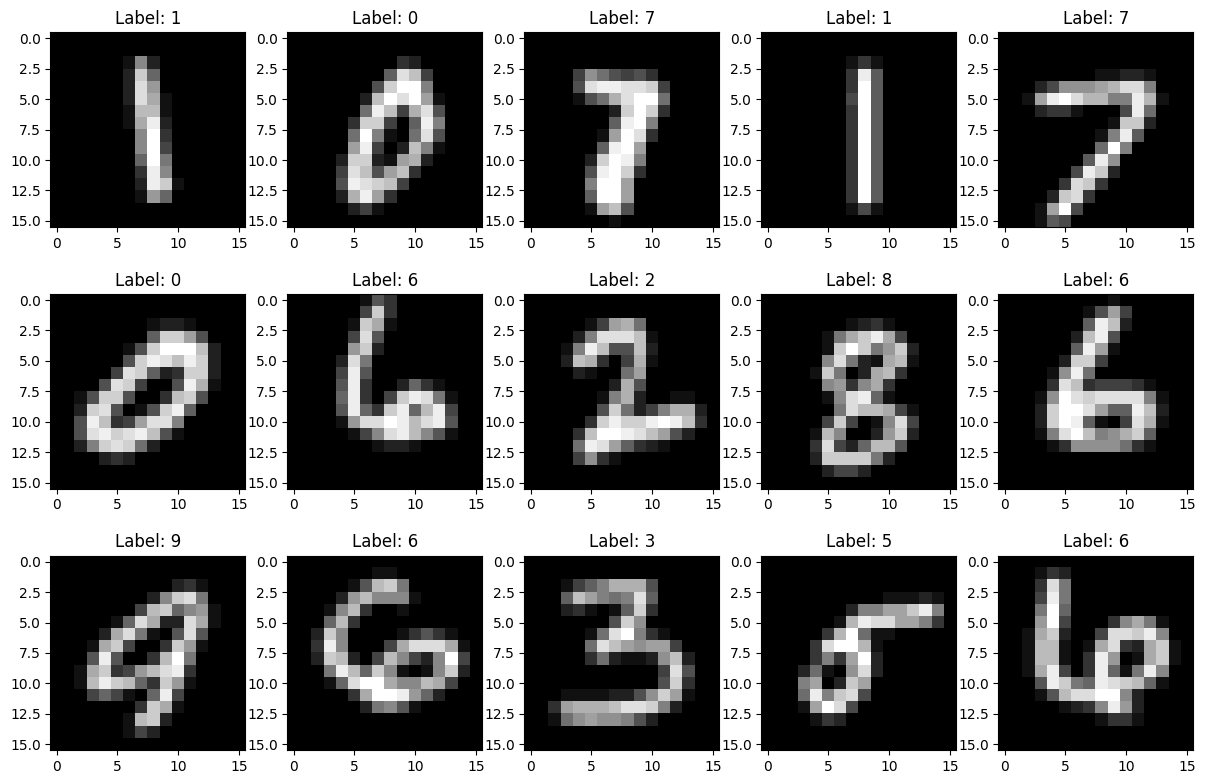

In [1]:
import sys
from pathlib import Path

# Ensure experiments/ is on the path so QNN_integration is importable
_experiments_dir = str(Path().absolute().parent)
if _experiments_dir not in sys.path:
    sys.path.insert(0, _experiments_dir)

import joblib
import numpy as np
from QNN_integration.datasets.dataset_structure import DataBlock,  DataSet, DatasetSplit
from pathlib import Path

seed = 71
rng = np.random.default_rng(seed)

mnist_digits_stratified_path = Path().absolute().parent / "QNN_integration" / "datasets" / "MNIST_Digits_5_subsets_train_val_test_16x16.joblib"
mnist_digits_stratified = joblib.load(mnist_digits_stratified_path)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 5, figsize=(12, 8))

axes = axes.flatten()
for ax in axes:
	i = rng.integers(0, len(mnist_digits_stratified.subsets[0].train.X))
	ax.imshow(mnist_digits_stratified.subsets[0].train.X[i], cmap=plt.cm.gray)
	ax.set_title("Label: " + str(mnist_digits_stratified.subsets[0].train.y[i]))

plt.tight_layout()
plt.show()


Experimental porotocol report - help functions.

In [2]:
from datetime import datetime

REPORT_WIDTH = 118
EPOCH_COLUMNS = [
	("Epoch", 9),
	("TrLoss", 8),
	("TrAcc", 8),
	("TrPrec", 8),
	("TrRec", 8),
	("TrF1", 8),
	("VaLoss", 8),
	("VaAcc", 8),
	("VaPrec", 8),
	("VaRec", 8),
	("VaF1", 8),
]


def _stringify_report_value(value):
	if isinstance(value, float):
		return f"{value:.4f}"
	if isinstance(value, (list, tuple)):
		return ", ".join(_stringify_report_value(item) for item in value)
	return str(value)



def _format_mapping(mapping):
	return ", ".join(
		f"{key}={_stringify_report_value(value)}"
		for key, value in mapping.items()
	)



def _wrap_report_line(prefix, value, width=REPORT_WIDTH):
	inner_width = width - 4
	text = f"{prefix}{_stringify_report_value(value)}"
	lines = []

	while len(text) > inner_width:
		split_at = text.rfind(" ", 0, inner_width + 1)
		if split_at <= len(prefix):
			split_at = inner_width
		lines.append(text[:split_at])
		text = (" " * len(prefix)) + text[split_at:].lstrip()

	lines.append(text)
	return [f"# {line.ljust(inner_width)} #" for line in lines]



def _render_report_box(title, rows, extra_lines=None, width=REPORT_WIDTH):
	inner_width = width - 4
	lines = [
		"#" * width,
		f"# {title.center(inner_width)} #",
		"#" * width,
	]

	for label, value in rows:
		lines.extend(_wrap_report_line(f"{label:<10}: ", value, width=width))

	for line in extra_lines or []:
		lines.extend(_wrap_report_line("", line, width=width))

	lines.append("#" * width)
	return "\n".join(lines)



def _make_table_border(fill='-'):
	return "+" + "+".join(fill * width for _, width in EPOCH_COLUMNS) + "+"



def _fit_table_value(value, width):
	text = _stringify_report_value(value)
	if len(text) > width:
		return text[:width]
	return text.rjust(width)



def count_trainable_parameters(model):
	return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)



def print_experiment_report(title, dataset_name, classifier_name, subset_name, split_sizes, training_setup, model_setup=None, model_architecture=None, trainable_parameters=None):
	now = datetime.now()
	rows = [
		("DATE", now.strftime("%d-%m-%Y")),
		("TIME", now.strftime("%H:%M")),
		("DATASET", dataset_name),
		("CLASSIFIER", classifier_name),
		("SUBSET", subset_name),
		("SPLITS", _format_mapping(split_sizes)),
		("TRAINING", _format_mapping(training_setup)),
	]

	if model_architecture:
		rows.append(("ARCHITECT.", model_architecture))

	if trainable_parameters is not None:
		rows.append(("PARAMS", trainable_parameters))

	if model_setup:
		rows.append(("MODEL", _format_mapping(model_setup)))

	print(_render_report_box(title, rows))



def print_epoch_table_header():
	print(_make_table_border('-'))
	print("|" + "|".join(f"{name:^{width}}" for name, width in EPOCH_COLUMNS) + "|")
	print(_make_table_border('='))



def print_epoch_table_row(epoch, epochs, train_loss, train_metrics, val_loss, val_metrics):
	row_values = [
		f"{epoch:03d}/{epochs:03d}",
		f"{train_loss:.4f}",
		f"{train_metrics['accuracy']:.4f}",
		f"{train_metrics['precision']:.4f}",
		f"{train_metrics['recall']:.4f}",
		f"{train_metrics['f1']:.4f}",
		f"{val_loss:.4f}",
		f"{val_metrics['accuracy']:.4f}",
		f"{val_metrics['precision']:.4f}",
		f"{val_metrics['recall']:.4f}",
		f"{val_metrics['f1']:.4f}",
	]
	print("|" + "|".join(_fit_table_value(value, width) for value, (_, width) in zip(row_values, EPOCH_COLUMNS)) + "|")



def print_epoch_table_footer():
	print(_make_table_border('-'))



def print_metrics_report(title, metrics, matrix=None):
	rows = [
		(name.upper(), _stringify_report_value(value))
		for name, value in metrics.items()
	]

	extra_lines = []
	if matrix is not None:
		extra_lines.append("CONFUSION MATRIX:")
		extra_lines.extend(
			np.array2string(
				np.asarray(matrix),
				max_line_width=REPORT_WIDTH - 6,
			).splitlines()
		)

	print(_render_report_box(title, rows, extra_lines=extra_lines))



def print_summary_report(title, summary):
	rows = [
		("ACCURACY", f"{summary['accuracy_mean']:.4f} +/- {summary['accuracy_std']:.4f}"),
		("PRECISION", f"{summary['precision_mean']:.4f} +/- {summary['precision_std']:.4f}"),
		("RECALL", f"{summary['recall_mean']:.4f} +/- {summary['recall_std']:.4f}"),
		("F1", f"{summary['f1_mean']:.4f} +/- {summary['f1_std']:.4f}"),
	]
	print(_render_report_box(title, rows))


# CLASSICAL BASELINE TESTS

#### Classical PyTorch baseline architectures: Dense and CNN

In [17]:
import torch
import torch.nn as nn
from torch.optim import Adam
import copy

from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	confusion_matrix
)

class DenseBaseline(nn.Module):
	def __init__(self, num_classes=10):
		super().__init__()
		self.flatten = nn.Flatten()
		self.classical_head_dense = nn.Linear(16 * 16, num_classes)

	def forward(self, x):
		x = self.flatten(x)
		x = self.classical_head_dense(x)
		return x
	
def numpy_images_to_torch(x_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	"""
	Konwersja obrazów uint8 [0, 255] -> float32 [0, 1].
	Obsługuje wejście o kształcie:
	- (N, 16, 16)
	- (16, 16) dla pojedynczej próbki
	"""
	x_np = np.asarray(x_np)

	if x_np.ndim == 2:
		x_np = np.expand_dims(x_np, axis=0)

	x_tensor = torch.tensor(x_np, dtype=torch.float32, device=device) / 255.0
	return x_tensor


def numpy_labels_to_torch(y_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	y_np = np.asarray(y_np)
	return torch.tensor(y_np, dtype=torch.long, device=device)


def compute_classification_metrics(y_true, y_pred):
	return {
		"accuracy": float(accuracy_score(y_true, y_pred)),
		"precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
		"recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
		"f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
	}


def evaluate_model(model, split, criterion, device="cpu", batch_size=32):
	"""
	Ewaluacja modelu na dowolnym splicie: train / val / test.
	Zwraca:
	- średnią stratę
	- metryki klasyfikacyjne
	- y_true, y_pred
	"""
	model.eval()

	x_all = numpy_images_to_torch(split.X, device=device)
	y_all = numpy_labels_to_torch(split.y, device=device)

	all_losses = []
	all_preds = []
	all_true = []

	with torch.no_grad():
		for start_idx in range(0, len(x_all), batch_size):
			end_idx = start_idx + batch_size

			x_batch = x_all[start_idx:end_idx]
			y_batch = y_all[start_idx:end_idx]

			logits = model(x_batch)
			loss = criterion(logits, y_batch)

			preds = torch.argmax(logits, dim=1)

			all_losses.append(loss.item())
			all_preds.extend(preds.cpu().numpy().tolist())
			all_true.extend(y_batch.cpu().numpy().tolist())

	metrics = compute_classification_metrics(all_true, all_preds)

	return {
		"loss": float(np.mean(all_losses)) if len(all_losses) > 0 else 0.0,
		"accuracy": metrics["accuracy"],
		"precision": metrics["precision"],
		"recall": metrics["recall"],
		"f1": metrics["f1"],
		"y_true": all_true,
		"y_pred": all_preds,
	}


def train_one_block(
	data_block,
	num_classes=10,
	epochs=20,
	batch_size=32,
	lr=1e-3,
	early_stopping=True,
	patience=5,
	min_delta=1e-4,
	device="cpu",
	verbose=True,
	report_context=None
):
	"""
	Trening pojedynczego DataBlock:
	- uczy na train
	- co epokę waliduje na val
	- na końcu testuje na test
	"""
	model = DenseBaseline(num_classes=num_classes).to(device)
	if report_context is not None and report_context.get("model_architecture") and "trainable_parameters" not in report_context:
		report_context = {
			**report_context,
			"trainable_parameters": count_trainable_parameters(model),
		}
	criterion = nn.CrossEntropyLoss()
	optimizer = Adam(model.parameters(), lr=lr)

	best_val_loss = np.inf
	best_model_state = None
	best_epoch = -1
	epochs_without_improvement = 0

	x_train = numpy_images_to_torch(data_block.train.X, device=device)
	y_train = numpy_labels_to_torch(data_block.train.y, device=device)

	history = {
		"train_loss": [],
		"train_accuracy": [],
		"train_precision": [],
		"train_recall": [],
		"train_f1": [],
		"val_loss": [],
		"val_accuracy": [],
		"val_precision": [],
		"val_recall": [],
		"val_f1": [],
	}
	
	best_model_state = None

	for epoch in range(epochs):
		model.train()

		indices = torch.randperm(len(x_train), device=device)

		epoch_losses = []
		epoch_preds = []
		epoch_true = []

		for start_idx in range(0, len(indices), batch_size):
			batch_idx = indices[start_idx:start_idx + batch_size]

			x_batch = x_train[batch_idx]
			y_batch = y_train[batch_idx]

			logits = model(x_batch)
			loss = criterion(logits, y_batch)

			optimizer.zero_grad()
			loss.backward()
			optimizer.step()

			preds = torch.argmax(logits, dim=1)

			epoch_losses.append(loss.item())
			epoch_preds.extend(preds.detach().cpu().numpy().tolist())
			epoch_true.extend(y_batch.detach().cpu().numpy().tolist())

		train_metrics = compute_classification_metrics(epoch_true, epoch_preds)
		train_loss = float(np.mean(epoch_losses)) if len(epoch_losses) > 0 else 0.0

		val_results = evaluate_model(
			model=model,
			split=data_block.val,
			criterion=criterion,
			device=device,
			batch_size=batch_size
		)

		history["train_loss"].append(train_loss)
		history["train_accuracy"].append(train_metrics["accuracy"])
		history["train_precision"].append(train_metrics["precision"])
		history["train_recall"].append(train_metrics["recall"])
		history["train_f1"].append(train_metrics["f1"])

		history["val_loss"].append(val_results["loss"])
		history["val_accuracy"].append(val_results["accuracy"])
		history["val_precision"].append(val_results["precision"])
		history["val_recall"].append(val_results["recall"])
		history["val_f1"].append(val_results["f1"])

		if val_results["loss"] < best_val_loss - min_delta:
			best_val_loss = val_results["loss"]
			best_epoch = epoch
			best_model_state = copy.deepcopy(model.state_dict())
			epochs_without_improvement = 0
		else:
			epochs_without_improvement += 1

		if early_stopping and epochs_without_improvement >= patience:
			print(f"Early stopping at epoch {epoch + 1}, best epoch was {best_epoch + 1}")
			break

		if verbose:
			if epoch == 0:
				if report_context is not None:
					print_experiment_report(**report_context)
				print_epoch_table_header()
			print_epoch_table_row(
				epoch=epoch + 1,
				epochs=epochs,
				train_loss=train_loss,
				train_metrics=train_metrics,
				val_loss=val_results["loss"],
				val_metrics=val_results
			)

	if verbose and epochs > 0:
		print_epoch_table_footer()

	if best_model_state is not None:
		model.load_state_dict(best_model_state)

	test_results = evaluate_model(
		model=model,
		split=data_block.test,
		criterion=criterion,
		device=device,
		batch_size=batch_size
	)

	test_cm = confusion_matrix(
		test_results["y_true"],
		test_results["y_pred"],
		labels=list(range(num_classes))
	)

	if verbose:
		print_metrics_report(
			title="TEST RESULTS",
			metrics={
				"loss": test_results["loss"],
				"accuracy": test_results["accuracy"],
				"precision": test_results["precision"],
				"recall": test_results["recall"],
				"f1": test_results["f1"],
			},
			matrix=test_cm
		)

	return {
		"model": model,
		"history": history,
		"test_metrics": {
			"loss": test_results["loss"],
			"accuracy": test_results["accuracy"],
			"precision": test_results["precision"],
			"recall": test_results["recall"],
			"f1": test_results["f1"],
		},
		"confusion_matrix": test_cm,
		"y_true": test_results["y_true"],
		"y_pred": test_results["y_pred"],
	}


def train_all_subsets(
	dataset,
	num_classes=10,
	epochs=20,
	batch_size=32,
	lr=1e-3,
	device="cpu",
	verbose=True
):
	"""
	Trening dla wszystkich 5 DataBlocków w dataset.subsets.
	Zwraca listę wyników dla każdego subsetu oraz agregację końcową.
	"""
	all_results = []

	for subset_idx, data_block in enumerate(dataset.subsets):
		report_context = {
			"title": "EXPERIMENTAL PROTOCOL REPORT",
			"dataset_name": "MNIST digits stratified",
			"classifier_name": "DenseBaseline",
			"model_architecture": "16x16 grayscale -> Flatten(256) -> Linear(256, num_classes)" if subset_idx == 0 else None,
			"subset_name": f"{subset_idx + 1}/{len(dataset.subsets)}",
			"split_sizes": {
				"train": len(data_block.train.X),
				"val": len(data_block.val.X),
				"test": len(data_block.test.X),
			},
			"training_setup": {
				"epochs": epochs,
				"batch_size": batch_size,
				"lr": lr,
				"device": device,
			},
			"model_setup": {
				"num_classes": num_classes,
			},
		}

		result = train_one_block(
			data_block=data_block,
			num_classes=num_classes,
			epochs=epochs,
			batch_size=batch_size,
			lr=lr,
			device=device,
			verbose=verbose,
			report_context=report_context
		)

		all_results.append(result)

	accuracies = [r["test_metrics"]["accuracy"] for r in all_results]
	precisions = [r["test_metrics"]["precision"] for r in all_results]
	recalls = [r["test_metrics"]["recall"] for r in all_results]
	f1s = [r["test_metrics"]["f1"] for r in all_results]

	summary = {
		"accuracy_mean": float(np.mean(accuracies)),
		"accuracy_std": float(np.std(accuracies)),
		"precision_mean": float(np.mean(precisions)),
		"precision_std": float(np.std(precisions)),
		"recall_mean": float(np.mean(recalls)),
		"recall_std": float(np.std(recalls)),
		"f1_mean": float(np.mean(f1s)),
		"f1_std": float(np.std(f1s)),
	}

	if verbose:
		print_summary_report("FINAL SUMMARY ACROSS SUBSETS", summary)

	return {
		"subset_results": all_results,
		"summary": summary
	}

results = train_all_subsets(
	dataset=mnist_digits_stratified,
	num_classes=10,
	epochs=10,
	batch_size=16,
	lr=1e-3,
	device="cpu",
	verbose=True
)

######################################################################################################################
#                                            EXPERIMENTAL PROTOCOL REPORT                                            #
######################################################################################################################
# DATE      : 22-04-2026                                                                                             #
# TIME      : 20:09                                                                                                  #
# DATASET   : MNIST digits stratified                                                                                #
# CLASSIFIER: DenseBaseline                                                                                          #
# SUBSET    : 1/5                                                                                                    #
# SPLITS    : train=921, val=231, test=288      

#### Baseline B: CNN

In [18]:
import copy
import numpy as np

import torch
import torch.nn as nn
from torch.optim import Adam

from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	confusion_matrix
)

class SimpleCNNBaseline(nn.Module):
	def __init__(self, num_classes=10):
		super().__init__()
		self.features = nn.Sequential(
			nn.Conv2d(1, 16, kernel_size=3, padding=1),
			nn.ReLU(),
			nn.MaxPool2d(kernel_size=2),

			nn.Conv2d(16, 32, kernel_size=3, padding=1),
			nn.ReLU(),
			nn.MaxPool2d(kernel_size=2)
		)

		self.classifier = nn.Sequential(
			nn.Flatten(),
			nn.Linear(32 * 4 * 4, 64),
			nn.ReLU(),
			nn.Linear(64, num_classes)
		)

	def forward(self, x):
		x = self.features(x)
		x = self.classifier(x)
		return x


def numpy_images_to_torch_cnn(x_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	"""
	Konwersja obrazów uint8 [0, 255] -> float32 [0, 1]
	oraz dodanie wymiaru kanału dla CNN.

	Wejście:
	- (N, 16, 16)
	- (16, 16)

	Wyjście:
	- (N, 1, 16, 16)
	"""
	x_np = np.asarray(x_np)

	if x_np.ndim == 2:
		x_np = np.expand_dims(x_np, axis=0)

	x_tensor = torch.tensor(x_np, dtype=torch.float32, device=device) / 255.0
	x_tensor = x_tensor.unsqueeze(1)
	return x_tensor


def numpy_labels_to_torch(y_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	y_np = np.asarray(y_np)
	return torch.tensor(y_np, dtype=torch.long, device=device)


def compute_classification_metrics(y_true, y_pred):
	return {
		"accuracy": float(accuracy_score(y_true, y_pred)),
		"precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
		"recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
		"f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
	}


def evaluate_cnn_model(model, split, criterion, device="cpu", batch_size=32):
	model.eval()

	x_all = numpy_images_to_torch_cnn(split.X, device=device)
	y_all = numpy_labels_to_torch(split.y, device=device)

	all_losses = []
	all_preds = []
	all_true = []

	with torch.no_grad():
		for start_idx in range(0, len(x_all), batch_size):
			end_idx = start_idx + batch_size

			x_batch = x_all[start_idx:end_idx]
			y_batch = y_all[start_idx:end_idx]

			logits = model(x_batch)
			loss = criterion(logits, y_batch)

			preds = torch.argmax(logits, dim=1)

			all_losses.append(loss.item())
			all_preds.extend(preds.cpu().numpy().tolist())
			all_true.extend(y_batch.cpu().numpy().tolist())

	metrics = compute_classification_metrics(all_true, all_preds)

	return {
		"loss": float(np.mean(all_losses)) if len(all_losses) > 0 else 0.0,
		"accuracy": metrics["accuracy"],
		"precision": metrics["precision"],
		"recall": metrics["recall"],
		"f1": metrics["f1"],
		"y_true": all_true,
		"y_pred": all_preds,
	}


def train_one_block_cnn(
	data_block,
	num_classes=10,
	epochs=20,
	batch_size=32,
	lr=1e-3,
	early_stopping=True,
	patience=5,
	min_delta=1e-4,
	device="cpu",
	verbose=True,
	report_context=None
):
	model = SimpleCNNBaseline(num_classes=num_classes).to(device)
	if report_context is not None and report_context.get("model_architecture") and "trainable_parameters" not in report_context:
		report_context = {
			**report_context,
			"trainable_parameters": count_trainable_parameters(model),
		}
	criterion = nn.CrossEntropyLoss()
	optimizer = Adam(model.parameters(), lr=lr)

	x_train = numpy_images_to_torch_cnn(data_block.train.X, device=device)
	y_train = numpy_labels_to_torch(data_block.train.y, device=device)

	history = {
		"train_loss": [],
		"train_accuracy": [],
		"train_precision": [],
		"train_recall": [],
		"train_f1": [],
		"val_loss": [],
		"val_accuracy": [],
		"val_precision": [],
		"val_recall": [],
		"val_f1": [],
	}

	best_val_loss = np.inf
	best_model_state = None
	best_epoch = -1
	epochs_without_improvement = 0

	for epoch in range(epochs):
		model.train()

		indices = torch.randperm(len(x_train), device=device)

		epoch_losses = []
		epoch_preds = []
		epoch_true = []

		for start_idx in range(0, len(indices), batch_size):
			batch_idx = indices[start_idx:start_idx + batch_size]

			x_batch = x_train[batch_idx]
			y_batch = y_train[batch_idx]

			logits = model(x_batch)
			loss = criterion(logits, y_batch)

			optimizer.zero_grad()
			loss.backward()
			optimizer.step()

			preds = torch.argmax(logits, dim=1)

			epoch_losses.append(loss.item())
			epoch_preds.extend(preds.detach().cpu().numpy().tolist())
			epoch_true.extend(y_batch.detach().cpu().numpy().tolist())

		train_metrics = compute_classification_metrics(epoch_true, epoch_preds)
		train_loss = float(np.mean(epoch_losses)) if len(epoch_losses) > 0 else 0.0

		val_results = evaluate_cnn_model(
			model=model,
			split=data_block.val,
			criterion=criterion,
			device=device,
			batch_size=batch_size
		)

		history["train_loss"].append(train_loss)
		history["train_accuracy"].append(train_metrics["accuracy"])
		history["train_precision"].append(train_metrics["precision"])
		history["train_recall"].append(train_metrics["recall"])
		history["train_f1"].append(train_metrics["f1"])

		history["val_loss"].append(val_results["loss"])
		history["val_accuracy"].append(val_results["accuracy"])
		history["val_precision"].append(val_results["precision"])
		history["val_recall"].append(val_results["recall"])
		history["val_f1"].append(val_results["f1"])

		if val_results["loss"] < best_val_loss - min_delta:
			best_val_loss = val_results["loss"]
			best_epoch = epoch
			best_model_state = copy.deepcopy(model.state_dict())
			epochs_without_improvement = 0
		else:
			epochs_without_improvement += 1

		if early_stopping and epochs_without_improvement >= patience:
			print(f"Early stopping at epoch {epoch + 1}, best epoch was {best_epoch + 1}")
			break

		if verbose:
			if epoch == 0:
				if report_context is not None:
					print_experiment_report(**report_context)
				print_epoch_table_header()
			print_epoch_table_row(
				epoch=epoch + 1,
				epochs=epochs,
				train_loss=train_loss,
				train_metrics=train_metrics,
				val_loss=val_results["loss"],
				val_metrics=val_results
			)

	if verbose and epochs > 0:
		print_epoch_table_footer()

	if best_model_state is not None:
		model.load_state_dict(best_model_state)

	test_results = evaluate_cnn_model(
		model=model,
		split=data_block.test,
		criterion=criterion,
		device=device,
		batch_size=batch_size
	)

	test_cm = confusion_matrix(
		test_results["y_true"],
		test_results["y_pred"],
		labels=list(range(num_classes))
	)

	if verbose:
		print_metrics_report(
			title="TEST RESULTS",
			metrics={
				"loss": test_results["loss"],
				"accuracy": test_results["accuracy"],
				"precision": test_results["precision"],
				"recall": test_results["recall"],
				"f1": test_results["f1"],
			},
			matrix=test_cm
		)

	return {
		"model": model,
		"history": history,
		"test_metrics": {
			"loss": test_results["loss"],
			"accuracy": test_results["accuracy"],
			"precision": test_results["precision"],
			"recall": test_results["recall"],
			"f1": test_results["f1"],
		},
		"confusion_matrix": test_cm,
		"y_true": test_results["y_true"],
		"y_pred": test_results["y_pred"],
	}


def train_all_subsets_cnn(
	dataset,
	num_classes=10,
	epochs=20,
	batch_size=32,
	lr=1e-3,
	device="cpu",
	verbose=True
):
	all_results = []

	for subset_idx, data_block in enumerate(dataset.subsets):
		report_context = {
			"title": "EXPERIMENTAL PROTOCOL REPORT",
			"dataset_name": "MNIST digits stratified",
			"classifier_name": "SimpleCNNBaseline",
			"model_architecture": "16x16 grayscale -> Conv2d(1,16,3,pad=1) -> ReLU -> MaxPool2d(2) -> Conv2d(16,32,3,pad=1) -> ReLU -> MaxPool2d(2) -> Flatten -> Linear(512,64) -> ReLU -> Linear(64, num_classes)" if subset_idx == 0 else None,
			"subset_name": f"{subset_idx + 1}/{len(dataset.subsets)}",
			"split_sizes": {
				"train": len(data_block.train.X),
				"val": len(data_block.val.X),
				"test": len(data_block.test.X),
			},
			"training_setup": {
				"epochs": epochs,
				"batch_size": batch_size,
				"lr": lr,
				"device": device,
			},
			"model_setup": {
				"num_classes": num_classes,
			},
		}

		result = train_one_block_cnn(
			data_block=data_block,
			num_classes=num_classes,
			epochs=epochs,
			batch_size=batch_size,
			lr=lr,
			device=device,
			verbose=verbose,
			report_context=report_context
		)

		all_results.append(result)

	accuracies = [r["test_metrics"]["accuracy"] for r in all_results]
	precisions = [r["test_metrics"]["precision"] for r in all_results]
	recalls = [r["test_metrics"]["recall"] for r in all_results]
	f1s = [r["test_metrics"]["f1"] for r in all_results]

	summary = {
		"accuracy_mean": float(np.mean(accuracies)),
		"accuracy_std": float(np.std(accuracies)),
		"precision_mean": float(np.mean(precisions)),
		"precision_std": float(np.std(precisions)),
		"recall_mean": float(np.mean(recalls)),
		"recall_std": float(np.std(recalls)),
		"f1_mean": float(np.mean(f1s)),
		"f1_std": float(np.std(f1s)),
	}

	if verbose:
		print_summary_report("FINAL SUMMARY ACROSS SUBSETS", summary)

	return {
		"subset_results": all_results,
		"summary": summary
	}


device = "cuda" if torch.cuda.is_available() else "cpu"

cnn_results = train_all_subsets_cnn(
	dataset=mnist_digits_stratified,
	num_classes=10,
	epochs=10,
	batch_size=64,
	lr=1e-3,
	device=device,
	verbose=True
)

######################################################################################################################
#                                            EXPERIMENTAL PROTOCOL REPORT                                            #
######################################################################################################################
# DATE      : 22-04-2026                                                                                             #
# TIME      : 20:09                                                                                                  #
# DATASET   : MNIST digits stratified                                                                                #
# CLASSIFIER: SimpleCNNBaseline                                                                                      #
# SUBSET    : 1/5                                                                                                    #
# SPLITS    : train=921, val=231, test=288      

# Hybrid baselines, with using *ZZ_feature_map* encoding

Baseline C: ($16\times 16$) $\to$ PCA $\to (12) \to$ *ZZ_feature_map* $\to$ QNN $\to$ Dense

In [ ]:
import copy
from xml.parsers.expat import model
import numpy as np

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

from sklearn.decomposition import PCA
from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	confusion_matrix
)

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.gradients import ParamShiftSamplerGradient, SPSASamplerGradient

def _build_vqc_circuit(num_qubits: int, num_layers: int = 1) -> QuantumCircuit:
	''' Builds VQC - Ansatz'''
	thetas = ParameterVector("theta", length=3 * num_qubits * num_layers)
	vqc = QuantumCircuit(num_qubits)
	for layer in range(num_layers):
		offset = layer * 3 * num_qubits
		for i in range(num_qubits):
			vqc.rx(thetas[offset + i], i)
		for i in range(num_qubits):
			vqc.ry(thetas[offset + num_qubits + i], i)
		for i in range(num_qubits):
			vqc.rz(thetas[offset + 2 * num_qubits + i], i)
		# Alternating brickwork entanglement
		if layer % 2 == 0:
			for i in range(0, num_qubits - 1, 2):
				vqc.cx(i, i + 1)
		else:
			for i in range(1, num_qubits - 1, 2):
				vqc.cx(i, i + 1)
			vqc.cx(num_qubits - 1, 0)
	return vqc

class TorchDatasetSplit(Dataset):
	def __init__(self, X, y, x_dtype=torch.float32, y_dtype=torch.long):
		self.X = torch.tensor(X, dtype=x_dtype)
		self.y = torch.tensor(y, dtype=y_dtype)

	def __len__(self):
		return len(self.X)

	def __getitem__(self, idx):
		return self.X[idx], self.y[idx]

class QNN_Baseline_PCA(nn.Module):
	def __init__(self,
					num_qubits: int = 4,
					num_layers: int = 3,
					num_classes: int = 2,
					shots: int = 1024,
					scale_output: bool = True,
					):
		super().__init__()
		self.num_qubits = num_qubits
		self.num_layers = num_layers
		self.num_classes = num_classes
		self.num_shots = shots
		self.scale_output = scale_output

		# Trainable quantum weights, registered as a proper nn.Parameter so
		# that optimisers, state_dict, and requires_grad all work out of the box.
		# Workers reconstruct the circuit independently via _build_vqc_circuit,
		# so the Qiskit QuantumCircuit object does not need to be stored here.
		num_params = 3 * num_qubits * num_layers
		self.quantum_weight = nn.Parameter(
			torch.empty(num_params).uniform_(-np.pi, np.pi)
		)
		vqc_circuit = _build_vqc_circuit(self.num_qubits, self.num_layers)
		feature_map = zz_feature_map(feature_dimension=self.num_qubits, reps=1)
		full_circuit = QuantumCircuit(self.num_qubits)
		full_circuit.compose(feature_map, inplace=True)
		full_circuit.compose(vqc_circuit, inplace=True)
		sampler = Sampler(default_shots=self.num_shots)
		grad_fn = SPSASamplerGradient(sampler=sampler)
		qnn = SamplerQNN(
			circuit=full_circuit,
			input_params=list(feature_map.parameters),
			weight_params=list(vqc_circuit.parameters),
			sampler=sampler,
			gradient=grad_fn,
		)
		self.qnn_pytorch_layer = TorchConnector(qnn, initial_weights=self.quantum_weight)
		self.classical_head = nn.Linear(2**num_qubits, num_classes)
		self.softmax = nn.LogSoftmax(dim=-1)

	def forward(self, x: torch.Tensor) -> torch.Tensor:
		# Forward pass of the QNN layer. This is where the quantum circuit is built and executed.
		x = self.qnn_pytorch_layer(x)
		x = x * (2 ** self.num_qubits)  # Scale the output to match the expected range for the classical head
		x = self.classical_head(x)
		x = self.softmax(x)
		return x

def reduce_dimensionality_of_images_with_pca(x_np: np.ndarray, 
											 pca: PCA, 
											 device="cpu") -> torch.Tensor:
	"""
	Transforms images using an already fitted PCA.
	Input:
	- (N, 16, 16) or (16, 16)
	Output:
	- torch tensor of shape (N, n_components)
	"""
	x_np = np.asarray(x_np)

	if x_np.ndim == 2:
		x_np = np.expand_dims(x_np, axis=0)

	x_np = x_np.astype(np.float32) / 255.0
	x_np = x_np.reshape(len(x_np), -1)
	x_np = pca.transform(x_np)

	x_tensor = torch.tensor(x_np, dtype=torch.float32, device=device)
	return x_tensor

def prepare_reduced_dataset_using_pca(data_block: DataBlock, n_components, device="cpu") -> list[Dataset]:
	x_train = np.asarray(data_block.train.X, dtype=np.float32).reshape(len(data_block.train.X), -1) / 255.0
	pca = PCA(n_components=n_components)
	pca.fit(x_train)

	x_train_reduced = reduce_dimensionality_of_images_with_pca(data_block.train.X, pca=pca, device=device)
	x_val_reduced = reduce_dimensionality_of_images_with_pca(data_block.val.X, pca=pca, device=device)
	x_test_reduced = reduce_dimensionality_of_images_with_pca(data_block.test.X, pca=pca, device=device)

	train_dataset = TorchDatasetSplit(x_train_reduced, data_block.train.y)
	val_dataset = TorchDatasetSplit(x_val_reduced, data_block.val.y)
	test_dataset = TorchDatasetSplit(x_test_reduced, data_block.test.y)

	train_loader = DataLoader(
		train_dataset,
		batch_size=16,
		shuffle=True,
		drop_last=False
	)

	val_loader = DataLoader(
		val_dataset,
		batch_size=16,
		shuffle=False,
		drop_last=False
	)

	test_loader = DataLoader(
		test_dataset,
		batch_size=16,
		shuffle=False,
		drop_last=False
	)
	return train_loader, val_loader, test_loader

def numpy_labels_to_torch(y_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	y_np = np.asarray(y_np)
	return torch.tensor(y_np, dtype=torch.long, device=device)


def compute_classification_metrics(y_true, y_pred):
	return {
		"accuracy": float(accuracy_score(y_true, y_pred)),
		"precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
		"recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
		"f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
	}


def evaluate_pca_qnn_model(model, data_loader: DataLoader, f_loss, device="cpu", batch_size=16):
	model.eval()

	all_losses = []
	all_preds = []
	all_true = []

	with torch.no_grad():
		for X_val, y_val in data_loader:
			logits = model(X_val)
			loss = f_loss(logits, y_val)
			preds = torch.argmax(logits, dim=1)

			all_losses.append(loss.item())
			all_preds.extend(preds.cpu().numpy().tolist())
			all_true.extend(y_val.cpu().numpy().tolist())

	metrics = compute_classification_metrics(all_true, all_preds)

	return {
		"loss": float(np.mean(all_losses)) if len(all_losses) > 0 else 0.0,
		"accuracy": metrics["accuracy"],
		"precision": metrics["precision"],
		"recall": metrics["recall"],
		"f1": metrics["f1"],
		"y_true": all_true,
		"y_pred": all_preds,
	}


def train_one_block_pca_qnn(
	data_block: DataBlock,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=20,
	batch_size=16,
	early_stopping=True,
    patience=5,
    min_delta=1e-4,
	device="cpu",
	verbose=True,
	report_context=None
):
	"""
	Trains one block:
	(16x16) -> PCA(12) -> ZZFeatureMap -> QNN -> Dense
	"""
	# pca = fit_pca_on_train_split(
	# 	train_X=data_block.train.X,
	# 	n_components=num_qubits
	# )
	train_loader, val_loader, test_loader = prepare_reduced_dataset_using_pca(data_block, 
																		   n_components=num_qubits,
																		   device=device)

	model = QNN_Baseline_PCA(
		num_classes=num_classes,
		num_qubits=num_qubits,
		num_layers=num_layers
	)
	if report_context is not None and report_context.get("model_architecture") and "trainable_parameters" not in report_context:
		report_context = {
			**report_context,
			"trainable_parameters": count_trainable_parameters(model),
		}

	f_loss = nn.NLLLoss()
	optimizer = Adam(([
		{"params": model.qnn_pytorch_layer.parameters(), "lr": 0.001},
		{"params": model.classical_head.parameters(), "lr": 0.01},
	]))

	# x_train: torch.Tensor = reduce_dimensionality_of_images_with_pca(data_block.train.X, pca=pca, device=device)

	# y_train: torch.Tensor = numpy_labels_to_torch(data_block.train.y, device=device)

	history = {
		"train_loss": [],
		"train_accuracy": [],
		"train_precision": [],
		"train_recall": [],
		"train_f1": [],
		"val_loss": [],
		"val_accuracy": [],
		"val_precision": [],
		"val_recall": [],
		"val_f1": [],
	}

	best_val_loss = np.inf
	best_model_state = None
	best_epoch = -1
	epochs_without_improvement = 0

	for epoch in range(epochs):
		model.train()

		epoch_losses = []
		epoch_preds = []
		epoch_true = []

		for X_batch, y_batch in train_loader:
			optimizer.zero_grad()
			output = model(X_batch)
			loss = f_loss(output, y_batch)
			loss.backward()
			epoch_losses.append(loss.item())
			optimizer.step()
			preds = torch.argmax(output, dim=1)
			epoch_preds.extend(preds.detach().cpu().numpy().tolist())
			epoch_true.extend(y_batch.detach().cpu().numpy().tolist())

		train_metrics = compute_classification_metrics(epoch_true, epoch_preds)
		train_loss = float(np.mean(epoch_losses)) if len(epoch_losses) > 0 else 0.0

		val_results = evaluate_pca_qnn_model(
			model=model,
			data_loader=val_loader,
			f_loss=f_loss,
			device=device,
			batch_size=batch_size
		)

		history["train_loss"].append(train_loss)
		history["train_accuracy"].append(train_metrics["accuracy"])
		history["train_precision"].append(train_metrics["precision"])
		history["train_recall"].append(train_metrics["recall"])
		history["train_f1"].append(train_metrics["f1"])

		history["val_loss"].append(val_results["loss"])
		history["val_accuracy"].append(val_results["accuracy"])
		history["val_precision"].append(val_results["precision"])
		history["val_recall"].append(val_results["recall"])
		history["val_f1"].append(val_results["f1"])

		if val_results["loss"] < best_val_loss - min_delta:
			best_val_loss = val_results["loss"]
			best_epoch = epoch
			best_model_state = copy.deepcopy(model.state_dict())
			epochs_without_improvement = 0
		else:
			epochs_without_improvement += 1

		if early_stopping and epochs_without_improvement >= patience:
			print(f"Early stopping at epoch {epoch + 1}, best epoch was {best_epoch + 1}")
			break

		if verbose:
			if epoch == 0:
				if report_context is not None:
					print_experiment_report(**report_context)
				print_epoch_table_header()
			print_epoch_table_row(
				epoch=epoch + 1,
				epochs=epochs,
				train_loss=train_loss,
				train_metrics=train_metrics,
				val_loss=val_results["loss"],
				val_metrics=val_results
			)
			
	if best_model_state is not None:
		model.load_state_dict(best_model_state)


	if verbose and epochs > 0:
		print_epoch_table_footer()

	test_results = evaluate_pca_qnn_model(
		model=model,
		data_loader=test_loader,
		f_loss=f_loss,
		device=device,
		batch_size=batch_size
	)

	test_cm = confusion_matrix(
		test_results["y_true"],
		test_results["y_pred"],
		labels=list(range(num_classes))
	)

	if verbose:
		print_metrics_report(
			title="TEST RESULTS",
			metrics={
				"loss": test_results["loss"],
				"accuracy": test_results["accuracy"],
				"precision": test_results["precision"],
				"recall": test_results["recall"],
				"f1": test_results["f1"],
			},
			matrix=test_cm
		)

	return {
		"model": model,
		"history": history,
		"test_metrics": {
			"loss": test_results["loss"],
			"accuracy": test_results["accuracy"],
			"precision": test_results["precision"],
			"recall": test_results["recall"],
			"f1": test_results["f1"],
		},
		"confusion_matrix": test_cm,
		"y_true": test_results["y_true"],
		"y_pred": test_results["y_pred"],
	}


def train_all_subsets_pca_qnn(
	dataset: DataSet,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=10,
	batch_size=32,
	device="cpu",
	verbose=True
):
	all_results = []

	for subset_idx, data_block in enumerate(dataset.subsets):
		report_context = {
			"title": "EXPERIMENTAL PROTOCOL REPORT",
			"dataset_name": "MNIST digits stratified",
			"classifier_name": "PCA + ZZFeatureMap + QNN",
			"model_architecture": "16x16 grayscale -> Flatten(256) -> PCA(num_qubits) -> ZZFeatureMap(reps=1) -> VQC[RX-RY-RZ x num_layers + brickwork CX] -> SamplerQNN -> Linear(2**num_qubits, num_classes) -> LogSoftmax" if subset_idx == 0 else None,
			"subset_name": f"{subset_idx + 1}/{len(dataset.subsets)}",
			"split_sizes": {
				"train": len(data_block.train.X),
				"val": len(data_block.val.X),
				"test": len(data_block.test.X),
			},
			"training_setup": {
				"epochs": epochs,
				"batch_size": batch_size,
				"device": device,
				"qnn_lr": 0.001,
				"head_lr": 0.01,
			},
			"model_setup": {
				"num_classes": num_classes,
				"num_qubits": num_qubits,
				"num_layers": num_layers,
			},
		}

		result = train_one_block_pca_qnn(
			data_block=data_block,
			num_classes=num_classes,
			num_qubits=num_qubits,
			num_layers=num_layers,
			epochs=epochs,
			batch_size=batch_size,
			device=device,
			verbose=verbose,
			report_context=report_context
		)

		all_results.append(result)

	accuracies = [r["test_metrics"]["accuracy"] for r in all_results]
	precisions = [r["test_metrics"]["precision"] for r in all_results]
	recalls = [r["test_metrics"]["recall"] for r in all_results]
	f1s = [r["test_metrics"]["f1"] for r in all_results]

	summary = {
		"accuracy_mean": float(np.mean(accuracies)),
		"accuracy_std": float(np.std(accuracies)),
		"precision_mean": float(np.mean(precisions)),
		"precision_std": float(np.std(precisions)),
		"recall_mean": float(np.mean(recalls)),
		"recall_std": float(np.std(recalls)),
		"f1_mean": float(np.mean(f1s)),
		"f1_std": float(np.std(f1s)),
	}

	if verbose:
		print_summary_report("FINAL SUMMARY ACROSS SUBSETS", summary)

	return {
		"subset_results": all_results,
		"summary": summary
	}


device = "cuda" if torch.cuda.is_available() else "cpu"

pca_qnn_results = train_all_subsets_pca_qnn(
	dataset=mnist_digits_stratified,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=10,
	batch_size=16,
	device=device,
	verbose=True
)

C:\Users\micha\AppData\Local\Temp\ipykernel_26532\51395203.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=x_dtype)
c:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


######################################################################################################################
#                                            EXPERIMENTAL PROTOCOL REPORT                                            #
######################################################################################################################
# DATE      : 14-04-2026                                                                                             #
# TIME      : 00:40                                                                                                  #
# DATASET   : MNIST digits stratified                                                                                #
# CLASSIFIER: PCA + ZZFeatureMap + QNN                                                                               #
# SUBSET    : 1/5                                                                                                    #
# SPLITS    : train=921, val=231, test=288      

C:\Users\micha\AppData\Local\Temp\ipykernel_26532\51395203.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=x_dtype)
c:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


######################################################################################################################
#                                            EXPERIMENTAL PROTOCOL REPORT                                            #
######################################################################################################################
# DATE      : 14-04-2026                                                                                             #
# TIME      : 01:18                                                                                                  #
# DATASET   : MNIST digits stratified                                                                                #
# CLASSIFIER: PCA + ZZFeatureMap + QNN                                                                               #
# SUBSET    : 2/5                                                                                                    #
# SPLITS    : train=921, val=231, test=288      

C:\Users\micha\AppData\Local\Temp\ipykernel_26532\51395203.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=x_dtype)
c:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


######################################################################################################################
#                                            EXPERIMENTAL PROTOCOL REPORT                                            #
######################################################################################################################
# DATE      : 14-04-2026                                                                                             #
# TIME      : 01:56                                                                                                  #
# DATASET   : MNIST digits stratified                                                                                #
# CLASSIFIER: PCA + ZZFeatureMap + QNN                                                                               #
# SUBSET    : 3/5                                                                                                    #
# SPLITS    : train=921, val=231, test=288      

C:\Users\micha\AppData\Local\Temp\ipykernel_26532\51395203.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=x_dtype)
c:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


######################################################################################################################
#                                            EXPERIMENTAL PROTOCOL REPORT                                            #
######################################################################################################################
# DATE      : 14-04-2026                                                                                             #
# TIME      : 02:35                                                                                                  #
# DATASET   : MNIST digits stratified                                                                                #
# CLASSIFIER: PCA + ZZFeatureMap + QNN                                                                               #
# SUBSET    : 4/5                                                                                                    #
# SPLITS    : train=921, val=231, test=288      

C:\Users\micha\AppData\Local\Temp\ipykernel_26532\51395203.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=x_dtype)
c:\Users\micha\OneDrive - Politechnika Śląska\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\qiskit_machine_learning\connectors\torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


######################################################################################################################
#                                            EXPERIMENTAL PROTOCOL REPORT                                            #
######################################################################################################################
# DATE      : 14-04-2026                                                                                             #
# TIME      : 03:13                                                                                                  #
# DATASET   : MNIST digits stratified                                                                                #
# CLASSIFIER: PCA + ZZFeatureMap + QNN                                                                               #
# SUBSET    : 5/5                                                                                                    #
# SPLITS    : train=921, val=231, test=288      

Baseline D: ($16\times 16$) $\to$ CNN $\to (12) \to$ *ZZ_feature_map* $\to$ QNN $\to$ Dense

In [4]:
import copy
import numpy as np

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	confusion_matrix
)

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.gradients import ParamShiftSamplerGradient, SPSASamplerGradient

def _build_vqc_circuit(num_qubits: int, num_layers: int = 1) -> QuantumCircuit:
	''' Builds VQC - Ansatz'''
	thetas = ParameterVector("theta", length=3 * num_qubits * num_layers)
	vqc = QuantumCircuit(num_qubits)
	for layer in range(num_layers):
		offset = layer * 3 * num_qubits
		for i in range(num_qubits):
			vqc.rx(thetas[offset + i], i)
		for i in range(num_qubits):
			vqc.ry(thetas[offset + num_qubits + i], i)
		for i in range(num_qubits):
			vqc.rz(thetas[offset + 2 * num_qubits + i], i)
		# Alternating brickwork entanglement
		if layer % 2 == 0:
			for i in range(0, num_qubits - 1, 2):
				vqc.cx(i, i + 1)
		else:
			for i in range(1, num_qubits - 1, 2):
				vqc.cx(i, i + 1)
			vqc.cx(num_qubits - 1, 0)
	return vqc

class TorchDatasetSplit(Dataset):
	def __init__(self, X, y, x_dtype=torch.float32, y_dtype=torch.long):
		self.X = torch.tensor(X, dtype=x_dtype)
		self.y = torch.tensor(y, dtype=y_dtype)

	def __len__(self):
		return len(self.X)

	def __getitem__(self, idx):
		return self.X[idx], self.y[idx]
	

class QNN_Baseline_CNN(nn.Module):
	def __init__(self,
					num_qubits: int = 4,
					num_layers: int = 3,
					num_classes: int = 2,
					shots: int = 1024,
					scale_output: bool = True,
					):
		super().__init__()
		self.num_qubits = num_qubits
		self.num_layers = num_layers
		self.num_classes = num_classes
		self.num_shots = shots
		self.scale_output = scale_output

		# Sprasować 
		self.cnn = nn.Sequential(
			nn.Conv2d(1, 16, kernel_size=3, padding=1),
			nn.ReLU(),
			nn.MaxPool2d(kernel_size=2),

			nn.Conv2d(16, 32, kernel_size=3, padding=1),
			nn.ReLU(),
			nn.MaxPool2d(kernel_size=2),
			nn.Flatten(),
			nn.Linear(32 * 4 * 4, num_qubits)
		)


		# Trainable quantum weights, registered as a proper nn.Parameter so
		# that optimisers, state_dict, and requires_grad all work out of the box.
		# Workers reconstruct the circuit independently via _build_vqc_circuit,
		# so the Qiskit QuantumCircuit object does not need to be stored here.
		num_params = 3 * num_qubits * num_layers
		self.quantum_weight = nn.Parameter(
			torch.empty(num_params).uniform_(-np.pi, np.pi)
		)
		vqc_circuit = _build_vqc_circuit(self.num_qubits, self.num_layers)
		feature_map = zz_feature_map(feature_dimension=self.num_qubits, reps=1)
		full_circuit = QuantumCircuit(self.num_qubits)
		full_circuit.compose(feature_map, inplace=True)
		full_circuit.compose(vqc_circuit, inplace=True)
		sampler = Sampler(default_shots=self.num_shots)
		grad_fn = SPSASamplerGradient(sampler=sampler)
		qnn = SamplerQNN(
			circuit=full_circuit,
			input_params=list(feature_map.parameters),
			weight_params=list(vqc_circuit.parameters),
			sampler=sampler,
			gradient=grad_fn,
		)
		self.qnn_pytorch_layer = TorchConnector(qnn, initial_weights=self.quantum_weight)
		self.classical_head = nn.Linear(2**num_qubits, num_classes)
		self.softmax = nn.LogSoftmax(dim=-1)

	def forward(self, x: torch.Tensor) -> torch.Tensor:
		# Forward pass of the QNN layer. This is where the quantum circuit is built and executed.
		if x.ndim == 3:
			x = x.unsqueeze(1)
		# Keep preprocessing comparable to the CNN baseline.
		x = x.float() / 255.0

		x = self.cnn(x)					# CNN: (N, 1, 16, 16) -> (N, num_qubits)
		x = self.qnn_pytorch_layer(x)	# QNN: (N, num_qubits) -> (N, 2**num_qubits)
		x = x * (2 ** self.num_qubits)  # Scale the output to match the expected range for the classical head
		x = self.classical_head(x)		# Dense: (N, 2**num_qubits) -> (N, num_classes)
		x = self.softmax(x)				# Softmax: (N, num_classes) -> (N, num_classes) with log-probabilities
		return x

def prepare_dataset_loaders(
	data_block: DataBlock,
	batch_size: int = 16,
) -> tuple[DataLoader, DataLoader, DataLoader]:

	train_dataset = TorchDatasetSplit(data_block.train.X, data_block.train.y)
	val_dataset = TorchDatasetSplit(data_block.val.X, data_block.val.y)
	test_dataset = TorchDatasetSplit(data_block.test.X, data_block.test.y)

	train_loader = DataLoader(
		train_dataset,
		batch_size=batch_size,
		shuffle=True,
		drop_last=False
	)

	val_loader = DataLoader(
		val_dataset,
		batch_size=batch_size,
		shuffle=False,
		drop_last=False
	)

	test_loader = DataLoader(
		test_dataset,
		batch_size=batch_size,
		shuffle=False,
		drop_last=False
	)
	return train_loader, val_loader, test_loader

def numpy_labels_to_torch(y_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	y_np = np.asarray(y_np)
	return torch.tensor(y_np, dtype=torch.long, device=device)


def compute_classification_metrics(y_true, y_pred):
	return {
		"accuracy": float(accuracy_score(y_true, y_pred)),
		"precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
		"recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
		"f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
	}


def evaluate_cnn_qnn_model(model, data_loader: DataLoader, f_loss, device="cpu", batch_size=16):
	model.eval()

	all_losses = []
	all_preds = []
	all_true = []

	with torch.no_grad():
		for X_val, y_val in data_loader:
			X_val = X_val.to(device)
			y_val = y_val.to(device)

			logits = model(X_val)
			loss = f_loss(logits, y_val)
			preds = torch.argmax(logits, dim=1)

			all_losses.append(loss.item())
			all_preds.extend(preds.cpu().numpy().tolist())
			all_true.extend(y_val.cpu().numpy().tolist())

	metrics = compute_classification_metrics(all_true, all_preds)

	return {
		"loss": float(np.mean(all_losses)) if len(all_losses) > 0 else 0.0,
		"accuracy": metrics["accuracy"],
		"precision": metrics["precision"],
		"recall": metrics["recall"],
		"f1": metrics["f1"],
		"y_true": all_true,
		"y_pred": all_preds,
	}


def train_one_block_cnn_qnn(
	data_block: DataBlock,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=20,
	batch_size=16,
	early_stopping=True,
    patience=5,
    min_delta=1e-4,
	device="cpu",
	verbose=True,
	report_context=None
):
	"""
	Trains one block:
	(16x16) -> CNN -> ZZFeatureMap -> QNN -> Dense
	"""
	train_loader, val_loader, test_loader = prepare_dataset_loaders(
		data_block,
		batch_size=batch_size,
	)

	model = QNN_Baseline_CNN(
		num_classes=num_classes,
		num_qubits=num_qubits,
		num_layers=num_layers
	).to(device)
	if report_context is not None and report_context.get("model_architecture") and "trainable_parameters" not in report_context:
		report_context = {
			**report_context,
			"trainable_parameters": count_trainable_parameters(model),
		}


	f_loss = nn.NLLLoss()
	optimizer = Adam(([
		{"params": model.cnn.parameters(), "lr": 0.001},
		{"params": model.qnn_pytorch_layer.parameters(), "lr": 0.001},
		{"params": model.classical_head.parameters(), "lr": 0.01},
	]))


	history = {
		"train_loss": [],
		"train_accuracy": [],
		"train_precision": [],
		"train_recall": [],
		"train_f1": [],
		"val_loss": [],
		"val_accuracy": [],
		"val_precision": [],
		"val_recall": [],
		"val_f1": [],
	}

	best_val_loss = np.inf
	best_model_state = None
	best_epoch = -1
	epochs_without_improvement = 0

	for epoch in range(epochs):
		model.train()

		epoch_losses = []
		epoch_preds = []
		epoch_true = []

		for X_batch, y_batch in train_loader:
			X_batch = X_batch.to(device)
			y_batch = y_batch.to(device)

			optimizer.zero_grad()
			output = model(X_batch)
			loss = f_loss(output, y_batch)
			loss.backward()			
			optimizer.step()

			epoch_losses.append(loss.item())
			preds = torch.argmax(output, dim=1)
			epoch_preds.extend(preds.detach().cpu().numpy().tolist())
			epoch_true.extend(y_batch.detach().cpu().numpy().tolist())

		train_metrics = compute_classification_metrics(epoch_true, epoch_preds)
		train_loss = float(np.mean(epoch_losses)) if len(epoch_losses) > 0 else 0.0

		val_results = evaluate_cnn_qnn_model(
			model=model,
			data_loader=val_loader,
			f_loss=f_loss,
			device=device,
			batch_size=batch_size
		)

		history["train_loss"].append(train_loss)
		history["train_accuracy"].append(train_metrics["accuracy"])
		history["train_precision"].append(train_metrics["precision"])
		history["train_recall"].append(train_metrics["recall"])
		history["train_f1"].append(train_metrics["f1"])

		history["val_loss"].append(val_results["loss"])
		history["val_accuracy"].append(val_results["accuracy"])
		history["val_precision"].append(val_results["precision"])
		history["val_recall"].append(val_results["recall"])
		history["val_f1"].append(val_results["f1"])

		if val_results["loss"] < best_val_loss - min_delta:
			best_val_loss = val_results["loss"]
			best_epoch = epoch
			best_model_state = copy.deepcopy(model.state_dict())
			epochs_without_improvement = 0
		else:
			epochs_without_improvement += 1

		if early_stopping and epochs_without_improvement >= patience:
			print(f"Early stopping at epoch {epoch + 1}, best epoch was {best_epoch + 1}")
			break


		if verbose:
			if epoch == 0:
				if report_context is not None:
					print_experiment_report(**report_context)
				print_epoch_table_header()
			print_epoch_table_row(
				epoch=epoch + 1,
				epochs=epochs,
				train_loss=train_loss,
				train_metrics=train_metrics,
				val_loss=val_results["loss"],
				val_metrics=val_results
			)


	if best_model_state is not None:
		model.load_state_dict(best_model_state)

	if verbose and epochs > 0:
		print_epoch_table_footer()

	test_results = evaluate_cnn_qnn_model(
		model=model,
		data_loader=test_loader,
		f_loss=f_loss,
		device=device,
		batch_size=batch_size
	)

	test_cm = confusion_matrix(
		test_results["y_true"],
		test_results["y_pred"],
		labels=list(range(num_classes))
	)

	if verbose:
		print_metrics_report(
			title="TEST RESULTS",
			metrics={
				"loss": test_results["loss"],
				"accuracy": test_results["accuracy"],
				"precision": test_results["precision"],
				"recall": test_results["recall"],
				"f1": test_results["f1"],
			},
			matrix=test_cm
		)

	return {
		"model": model,
		"history": history,
		"test_metrics": {
			"loss": test_results["loss"],
			"accuracy": test_results["accuracy"],
			"precision": test_results["precision"],
			"recall": test_results["recall"],
			"f1": test_results["f1"],
		},
		"confusion_matrix": test_cm,
		"y_true": test_results["y_true"],
		"y_pred": test_results["y_pred"],
	}


def train_all_subsets_cnn_qnn(
	dataset: DataSet,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=10,
	batch_size=32,
	device="cpu",
	verbose=True
):
	all_results = []

	for subset_idx, data_block in enumerate(dataset.subsets):
		report_context = {
			"title": "EXPERIMENTAL PROTOCOL REPORT",
			"dataset_name": "MNIST digits stratified",
			"classifier_name": "CNN + ZZFeatureMap + QNN",
			"model_architecture": "16x16 grayscale -> Conv2d(1,16,3,pad=1) -> ReLU -> MaxPool2d(2) -> Conv2d(16,32,3,pad=1) -> ReLU -> MaxPool2d(2) -> Flatten -> Linear(512, num_qubits) -> ZZFeatureMap(reps=1) -> VQC[RX-RY-RZ x num_layers + brickwork CX] -> SamplerQNN -> Linear(2**num_qubits, num_classes) -> LogSoftmax" if subset_idx == 0 else None,
			"subset_name": f"{subset_idx + 1}/{len(dataset.subsets)}",
			"split_sizes": {
				"train": len(data_block.train.X),
				"val": len(data_block.val.X),
				"test": len(data_block.test.X),
			},
			"training_setup": {
				"epochs": epochs,
				"batch_size": batch_size,
				"device": device,
				"qnn_lr": 0.001,
				"head_lr": 0.01,
			},
			"model_setup": {
				"num_classes": num_classes,
				"num_qubits": num_qubits,
				"num_layers": num_layers,
			},
		}

		result = train_one_block_cnn_qnn(
			data_block=data_block,
			num_classes=num_classes,
			num_qubits=num_qubits,
			num_layers=num_layers,
			epochs=epochs,
			batch_size=batch_size,
			device=device,
			verbose=verbose,
			report_context=report_context
		)

		all_results.append(result)

	accuracies = [r["test_metrics"]["accuracy"] for r in all_results]
	precisions = [r["test_metrics"]["precision"] for r in all_results]
	recalls = [r["test_metrics"]["recall"] for r in all_results]
	f1s = [r["test_metrics"]["f1"] for r in all_results]

	summary = {
		"accuracy_mean": float(np.mean(accuracies)),
		"accuracy_std": float(np.std(accuracies)),
		"precision_mean": float(np.mean(precisions)),
		"precision_std": float(np.std(precisions)),
		"recall_mean": float(np.mean(recalls)),
		"recall_std": float(np.std(recalls)),
		"f1_mean": float(np.mean(f1s)),
		"f1_std": float(np.std(f1s)),
	}

	if verbose:
		print_summary_report("FINAL SUMMARY ACROSS SUBSETS", summary)

	return {
		"subset_results": all_results,
		"summary": summary
	}


device = "cpu"

cnn_qnn_results = train_all_subsets_cnn_qnn(
	dataset=mnist_digits_stratified,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=10,
	batch_size=16,
	device=device,
	verbose=True
)

ModuleNotFoundError: No module named 'torch'

# GEQIE EXPERIMENTS
We are using GEQIE in order to encode feature vector for QNN

Experiment A: FRQI encoding + VQC + Dense

In [3]:
import copy
import glob
import numpy as np
import os

from multiprocessing import cpu_count
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	confusion_matrix
)

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.gradients import ParamShiftSamplerGradient, SPSASamplerGradient

import geqie
from geqie.encodings import frqi

from geqie_qml import VQCLayer, MatrixDataset, compute_and_save_circuits


class TorchDatasetSplit(Dataset):
	def __init__(self, X, y, x_dtype=torch.float32, y_dtype=torch.long):
		self.X = torch.tensor(X, dtype=x_dtype)
		self.y = torch.tensor(y, dtype=y_dtype)

	def __len__(self):
		return len(self.X)

	def __getitem__(self, idx):
		return self.X[idx], self.y[idx]
	
class QNN_GEQIE_FRQI(nn.Module):
	def __init__(self,
					num_qubits: int = 4,
					num_layers: int = 3,
					num_classes: int = 2,
					shots: int = 1024,
					scale_output: bool = True,
					encoding_method: str = "frqi",
					):
		super().__init__()
		self.num_qubits = num_qubits
		self.num_layers = num_layers
		self.num_classes = num_classes
		self.num_shots = shots
		self.scale_output = scale_output
		self.encoding_method = encoding_method

		# Trainable quantum weights, registered as a proper nn.Parameter so
		# that optimisers, state_dict, and requires_grad all work out of the box.
		# Workers reconstruct the circuit independently via _build_vqc_circuit,
		# so the Qiskit QuantumCircuit object does not need to be stored here.
		num_params = 3 * num_qubits * num_layers
		self.quantum_weight = nn.Parameter(
			torch.empty(num_params).uniform_(-np.pi, np.pi)
		)
		self.vqc_layer = VQCLayer(num_qubits=num_qubits, num_layers=num_layers)
		self.classical_head = nn.Linear(2**num_qubits, num_classes)
		self.softmax = nn.LogSoftmax(dim=-1)

	def forward(self, x: torch.Tensor) -> torch.Tensor:
		x = self.vqc_layer(x)	# QNN: (N, num_qubits) -> (N, 2**num_qubits)
		x = self.classical_head(x)		# Dense: (N, 2**num_qubits) -> (N, num_classes)
		x = self.softmax(x)				# Softmax: (N, num_classes) -> (N, num_classes) with log-probabilities
		return x



def numpy_labels_to_torch(y_np: np.ndarray, device: str = "cpu") -> torch.Tensor:
	y_np = np.asarray(y_np)
	return torch.tensor(y_np, dtype=torch.long, device=device)


def compute_classification_metrics(y_true, y_pred):
	return {
		"accuracy": float(accuracy_score(y_true, y_pred)),
		"precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
		"recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
		"f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
	}


def evaluate_cnn_qnn_model(model, data_loader: DataLoader, f_loss, device="cpu", batch_size=16):
	model.eval()

	all_losses = []
	all_preds = []
	all_true = []

	with torch.no_grad():
		for X_val, y_val in data_loader:
			X_val = X_val.to(device)
			y_val = y_val.to(device)

			logits = model(X_val)
			loss = f_loss(logits, y_val)
			preds = torch.argmax(logits, dim=1)

			all_losses.append(loss.item())
			all_preds.extend(preds.cpu().numpy().tolist())
			all_true.extend(y_val.cpu().numpy().tolist())

	metrics = compute_classification_metrics(all_true, all_preds)

	return {
		"loss": float(np.mean(all_losses)) if len(all_losses) > 0 else 0.0,
		"accuracy": metrics["accuracy"],
		"precision": metrics["precision"],
		"recall": metrics["recall"],
		"f1": metrics["f1"],
		"y_true": all_true,
		"y_pred": all_preds,
	}

def load_circuits(geqie_circuits_path: str,
				  batch_size: int = 16) -> tuple[DataLoader, DataLoader, DataLoader]:
	train_files = sorted(glob.glob(f"{geqie_circuits_path}/train/*.npz"))
	val_files = sorted(glob.glob(f"{geqie_circuits_path}/val/*.npz"))
	test_files = sorted(glob.glob(f"{geqie_circuits_path}/test/*.npz"))

	train_dataset = MatrixDataset(train_files)
	train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

	val_dataset = MatrixDataset(val_files)
	val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

	test_dataset = MatrixDataset(test_files)
	test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

	return train_dataloader, val_dataloader, test_dataloader


def train_one_block_frqi_qnn(
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=20,
	batch_size=16,
	device="cpu",
	geqie_circuits_path=None,
	verbose=True,
	report_context=None,
	early_stopping=True,
    patience=5,
    min_delta=1e-4,
):
	"""
	Trains one block:
	(16x16) -> CNN -> ZZFeatureMap -> QNN -> Dense
	"""
	# transform the datablock into set of matrices, encoded by GEQIE core.
	train_loader, val_loader, test_loader = load_circuits(geqie_circuits_path=geqie_circuits_path, batch_size=batch_size)

	vqc_layer = VQCLayer(
		num_qubits=num_qubits,
		num_layers=num_layers
	).to(device)
	
	model = nn.Sequential(
		vqc_layer,
		nn.Linear(2 ** num_qubits, num_classes),
		nn.LogSoftmax(dim=-1),
	)
	if report_context is not None and report_context.get("model_architecture") and "trainable_parameters" not in report_context:
		report_context = {
			**report_context,
			"trainable_parameters": count_trainable_parameters(model),
		}

	f_loss = nn.NLLLoss()
	optimizer = Adam(([
		{"params": model[0].parameters(), "lr": 0.001},
		{"params": model[1].parameters(), "lr": 0.01},
	]))


	history = {
		"train_loss": [],
		"train_accuracy": [],
		"train_precision": [],
		"train_recall": [],
		"train_f1": [],
		"val_loss": [],
		"val_accuracy": [],
		"val_precision": [],
		"val_recall": [],
		"val_f1": [],
	}

	best_val_loss = np.inf
	best_model_state = None
	best_epoch = -1
	epochs_without_improvement = 0

	with vqc_layer.parallel_context(num_workers=max(1, cpu_count() - 1)):
		for epoch in range(epochs):
			model.train()

			epoch_losses = []
			epoch_preds = []
			epoch_true = []

			for X_batch, y_batch in train_loader:
				X_batch = X_batch.to(device)
				y_batch = y_batch.to(device)

				optimizer.zero_grad()
				output = model(X_batch)
				loss = f_loss(output, y_batch)
				loss.backward()			
				optimizer.step()

				epoch_losses.append(loss.item())
				preds = torch.argmax(output, dim=1)
				epoch_preds.extend(preds.detach().cpu().numpy().tolist())
				epoch_true.extend(y_batch.detach().cpu().numpy().tolist())

			train_metrics = compute_classification_metrics(epoch_true, epoch_preds)
			train_loss = float(np.mean(epoch_losses)) if len(epoch_losses) > 0 else 0.0

			val_results = evaluate_cnn_qnn_model(
				model=model,
				data_loader=val_loader,
				f_loss=f_loss,
				device=device,
				batch_size=batch_size
			)

			history["train_loss"].append(train_loss)
			history["train_accuracy"].append(train_metrics["accuracy"])
			history["train_precision"].append(train_metrics["precision"])
			history["train_recall"].append(train_metrics["recall"])
			history["train_f1"].append(train_metrics["f1"])

			history["val_loss"].append(val_results["loss"])
			history["val_accuracy"].append(val_results["accuracy"])
			history["val_precision"].append(val_results["precision"])
			history["val_recall"].append(val_results["recall"])
			history["val_f1"].append(val_results["f1"])

			if val_results["loss"] < best_val_loss - min_delta:
				best_val_loss = val_results["loss"]
				best_epoch = epoch
				best_model_state = copy.deepcopy(model.state_dict())
				epochs_without_improvement = 0
			else:
				epochs_without_improvement += 1

			if early_stopping and epochs_without_improvement >= patience:
				if verbose:
					print(f"Early stopping at epoch {epoch + 1}, best epoch was {best_epoch + 1}")
				break

			if verbose:
				if epoch == 0:
					if report_context is not None:
						print_experiment_report(**report_context)
					print_epoch_table_header()
				print_epoch_table_row(
					epoch=epoch + 1,
					epochs=epochs,
					train_loss=train_loss,
					train_metrics=train_metrics,
					val_loss=val_results["loss"],
					val_metrics=val_results
				)			

		if verbose and epochs > 0:
			print_epoch_table_footer()

		if best_model_state is not None:
			model.load_state_dict(best_model_state)

		test_results = evaluate_cnn_qnn_model(
			model=model,
			data_loader=test_loader,
			f_loss=f_loss,
			device=device,
			batch_size=batch_size
		)

		test_cm = confusion_matrix(
			test_results["y_true"],
			test_results["y_pred"],
			labels=list(range(num_classes))
		)

		if verbose:
			print_metrics_report(
				title="TEST RESULTS",
				metrics={
					"loss": test_results["loss"],
					"accuracy": test_results["accuracy"],
					"precision": test_results["precision"],
					"recall": test_results["recall"],
					"f1": test_results["f1"],
				},
				matrix=test_cm 
			)

		return {
			"model": model,
			"history": history,
			"test_metrics": {
				"loss": test_results["loss"],
				"accuracy": test_results["accuracy"],
				"precision": test_results["precision"],
				"recall": test_results["recall"],
				"f1": test_results["f1"],
			},
			"confusion_matrix": test_cm,
			"y_true": test_results["y_true"],
			"y_pred": test_results["y_pred"],
		}


def train_all_subsets_frqi_qnn(
	dataset: DataSet,
	create_circuits: bool = True,
	encoding_method = frqi,
	num_classes=10,
	num_qubits=12,
	num_layers=1,
	epochs=10,
	batch_size=32,
	device="cpu",
	geqie_circuits_path="./datasets/circuits",
	verbose=True
):
	all_results = []

	cwd = os.getcwd()
	save_dir = os.path.join(cwd, geqie_circuits_path)
	if create_circuits:
		for subset_idx, data_block in enumerate(dataset.subsets):
			compute_and_save_circuits(data=data_block.train.X, 
								labels=data_block.train.y, 
								geqie_encoding=encoding_method, 
								save_dir=os.path.join(save_dir, f"subset_{subset_idx + 1}", "train"))

			compute_and_save_circuits(data=data_block.val.X, 
									labels=data_block.val.y, 
									geqie_encoding=encoding_method, 
									save_dir=os.path.join(save_dir, f"subset_{subset_idx + 1}", "val"))
			
			compute_and_save_circuits(data=data_block.test.X, 
									labels=data_block.test.y, 
									geqie_encoding=encoding_method,
									save_dir=os.path.join(save_dir, f"subset_{subset_idx + 1}", "test"))

	for subset_idx, data_block in enumerate(dataset.subsets):
		report_context = {
			"title": "EXPERIMENTAL PROTOCOL REPORT",
			"dataset_name": "MNIST digits stratified",
			"classifier_name": "CNN + ZZFeatureMap + QNN",
			"model_architecture": "GEQIE/FRQI-encoded circuits -> VQCLayer(num_qubits, num_layers) -> Linear(2**num_qubits, num_classes) -> LogSoftmax" if subset_idx == 0 else None,
			"subset_name": f"{subset_idx + 1}/{len(dataset.subsets)}",
			"split_sizes": {
				"train": len(data_block.train.X),
				"val": len(data_block.val.X),
				"test": len(data_block.test.X),
			},
			"training_setup": {
				"epochs": epochs,
				"batch_size": batch_size,
				"device": device,
				"qnn_lr": 0.001,
				"head_lr": 0.01,
			},
			"model_setup": {
				"num_classes": num_classes,
				"num_qubits": num_qubits,
				"num_layers": num_layers,
			},
		}

		result = train_one_block_frqi_qnn(
			geqie_circuits_path=os.path.join(save_dir, f"subset_{subset_idx + 1}"),
			num_classes=num_classes,
			num_qubits=num_qubits,
			num_layers=num_layers,
			epochs=epochs,
			batch_size=batch_size,
			device=device,
			verbose=verbose,
			report_context=report_context
		)

		all_results.append(result)

	accuracies = [r["test_metrics"]["accuracy"] for r in all_results]
	precisions = [r["test_metrics"]["precision"] for r in all_results]
	recalls = [r["test_metrics"]["recall"] for r in all_results]
	f1s = [r["test_metrics"]["f1"] for r in all_results]

	summary = {
		"accuracy_mean": float(np.mean(accuracies)),
		"accuracy_std": float(np.std(accuracies)),
		"precision_mean": float(np.mean(precisions)),
		"precision_std": float(np.std(precisions)),
		"recall_mean": float(np.mean(recalls)),
		"recall_std": float(np.std(recalls)),
		"f1_mean": float(np.mean(f1s)),
		"f1_std": float(np.std(f1s)),
	}

	if verbose:
		print_summary_report("FINAL SUMMARY ACROSS SUBSETS", summary)

	return {
		"subset_results": all_results,
		"summary": summary
	}

frqi_qnn_results = train_all_subsets_frqi_qnn(
	dataset=mnist_digits_stratified,
	create_circuits=True,
	encoding_method="frqi",
	num_classes=10,
	num_qubits=9,
	num_layers=1,
	epochs=10,
	batch_size=16,
	device="cpu",
	verbose=True
)

/Users/krzysztofwerner/git/geqie/experiments/QNN_integration/./datasets/circuits/subset_1/train/matrix_3 saved
/Users/krzysztofwerner/git/geqie/experiments/QNN_integration/./datasets/circuits/subset_1/train/matrix_1 saved
/Users/krzysztofwerner/git/geqie/experiments/QNN_integration/./datasets/circuits/subset_1/train/matrix_5 saved
/Users/krzysztofwerner/git/geqie/experiments/QNN_integration/./datasets/circuits/subset_1/train/matrix_4 saved
/Users/krzysztofwerner/git/geqie/experiments/QNN_integration/./datasets/circuits/subset_1/train/matrix_2 saved
/Users/krzysztofwerner/git/geqie/experiments/QNN_integration/./datasets/circuits/subset_1/train/matrix_6 saved
/Users/krzysztofwerner/git/geqie/experiments/QNN_integration/./datasets/circuits/subset_1/train/matrix_0 saved


KeyboardInterrupt: 

/Users/krzysztofwerner/git/geqie/experiments/QNN_integration/./datasets/circuits/subset_1/train/matrix_20 saved


# QEC EXPERIMENTS
Quantum Error Correction encoding is inserted **between** the GEQIE image unitary and the VQC ansatz.

Circuit: $|0\rangle^{\otimes N} \to [\text{Image Unitary on logical qubits}] \to [\text{QEC encode}] \to [\text{VQC on } N \text{ physical qubits}] \to [\text{Sample}]$

The precomputed `.npz` unitary matrices are **reused** — QEC encoding happens at circuit construction time inside `VQCLayer`.

## Experiment A: FRQI encoding + BitFlipCode QEC + VQC + Dense
FRQI encodes $16 \times 16$ images into 9 qubits. BitFlipCode [[3,1,1]] expands each logical qubit to 3 physical → $9 \times 3 = 27$ total qubits → $2^{27}$ output dimension.

**Warning**: $2^{27} = 134\,217\,728$ output dimension is very large

In [ ]:
import copy
import glob
import numpy as np
import os

from multiprocessing import cpu_count
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	confusion_matrix
)

from geqie_qml import VQCLayer, MatrixDataset, compute_and_save_circuits, BitFlipCode


def compute_classification_metrics(y_true, y_pred):
	return {
		"accuracy": float(accuracy_score(y_true, y_pred)),
		"precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
		"recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
		"f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
	}


def evaluate_qec_model(model, data_loader, f_loss, device="cpu"):
	model.eval()
	all_losses, all_preds, all_true = [], [], []
	with torch.no_grad():
		for X_val, y_val in data_loader:
			X_val, y_val = X_val.to(device), y_val.to(device)
			logits = model(X_val)
			loss = f_loss(logits, y_val)
			preds = torch.argmax(logits, dim=1)
			all_losses.append(loss.item())
			all_preds.extend(preds.cpu().numpy().tolist())
			all_true.extend(y_val.cpu().numpy().tolist())
	metrics = compute_classification_metrics(all_true, all_preds)
	return {
		"loss": float(np.mean(all_losses)) if all_losses else 0.0,
		**metrics,
		"y_true": all_true,
		"y_pred": all_preds,
	}


def load_circuits(geqie_circuits_path, batch_size=16):
	train_files = sorted(glob.glob(f"{geqie_circuits_path}/train/*.npz"))
	val_files = sorted(glob.glob(f"{geqie_circuits_path}/val/*.npz"))
	test_files = sorted(glob.glob(f"{geqie_circuits_path}/test/*.npz"))
	return (
		DataLoader(MatrixDataset(train_files), batch_size=batch_size, shuffle=True),
		DataLoader(MatrixDataset(val_files), batch_size=batch_size, shuffle=False),
		DataLoader(MatrixDataset(test_files), batch_size=batch_size, shuffle=False),
	)


def train_one_block_qec(
	num_classes=10,
	num_qubits=9,
	num_layers=1,
	qec_code=None,
	epochs=10,
	batch_size=16,
	device="cpu",
	geqie_circuits_path=None,
	verbose=True,
	report_context=None,
	early_stopping=True,
	patience=5,
	min_delta=1e-4,
):
	train_loader, val_loader, test_loader = load_circuits(
		geqie_circuits_path=geqie_circuits_path, batch_size=batch_size
	)

	vqc_layer = VQCLayer(
		num_qubits=num_qubits,
		num_layers=num_layers,
		qec_code=qec_code,
	).to(device)

	model = nn.Sequential(
		vqc_layer,
		nn.Linear(vqc_layer.output_dim, num_classes),
		nn.LogSoftmax(dim=-1),
	)

	if report_context is not None and report_context.get("model_architecture") and "trainable_parameters" not in report_context:
		report_context = {
			**report_context,
			"trainable_parameters": count_trainable_parameters(model),
		}

	f_loss = nn.NLLLoss()
	optimizer = Adam([
		{"params": model[0].parameters(), "lr": 0.001},
		{"params": model[1].parameters(), "lr": 0.01},
	])

	history = {k: [] for k in [
		"train_loss", "train_accuracy", "train_precision", "train_recall", "train_f1",
		"val_loss", "val_accuracy", "val_precision", "val_recall", "val_f1",
	]}

	best_val_loss = np.inf
	best_model_state = None
	best_epoch = -1
	epochs_without_improvement = 0

	with vqc_layer.parallel_context(num_workers=max(1, cpu_count() - 1)):
		for epoch in range(epochs):
			model.train()
			epoch_losses, epoch_preds, epoch_true = [], [], []

			for X_batch, y_batch in train_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				optimizer.zero_grad()
				output = model(X_batch)
				loss = f_loss(output, y_batch)
				loss.backward()
				optimizer.step()
				epoch_losses.append(loss.item())
				preds = torch.argmax(output, dim=1)
				epoch_preds.extend(preds.detach().cpu().numpy().tolist())
				epoch_true.extend(y_batch.detach().cpu().numpy().tolist())

			train_metrics = compute_classification_metrics(epoch_true, epoch_preds)
			train_loss = float(np.mean(epoch_losses)) if epoch_losses else 0.0

			val_results = evaluate_qec_model(model, val_loader, f_loss, device)

			history["train_loss"].append(train_loss)
			for key in ["accuracy", "precision", "recall", "f1"]:
				history[f"train_{key}"].append(train_metrics[key])
				history[f"val_{key}"].append(val_results[key])
			history["val_loss"].append(val_results["loss"])

			if val_results["loss"] < best_val_loss - min_delta:
				best_val_loss = val_results["loss"]
				best_epoch = epoch
				best_model_state = copy.deepcopy(model.state_dict())
				epochs_without_improvement = 0
			else:
				epochs_without_improvement += 1

			if early_stopping and epochs_without_improvement >= patience:
				if verbose:
					print(f"Early stopping at epoch {epoch + 1}, best epoch was {best_epoch + 1}")
				break

			if verbose:
				if epoch == 0:
					if report_context is not None:
						print_experiment_report(**report_context)
					print_epoch_table_header()
				print_epoch_table_row(epoch + 1, epochs, train_loss, train_metrics, val_results["loss"], val_results)

		if verbose and epochs > 0:
			print_epoch_table_footer()

		if best_model_state is not None:
			model.load_state_dict(best_model_state)

		test_results = evaluate_qec_model(model, test_loader, f_loss, device)
		test_cm = confusion_matrix(test_results["y_true"], test_results["y_pred"], labels=list(range(num_classes)))

		if verbose:
			print_metrics_report(
				title="TEST RESULTS",
				metrics={k: test_results[k] for k in ["loss", "accuracy", "precision", "recall", "f1"]},
				matrix=test_cm,
			)

		return {
			"model": model,
			"history": history,
			"test_metrics": {k: test_results[k] for k in ["loss", "accuracy", "precision", "recall", "f1"]},
			"confusion_matrix": test_cm,
			"y_true": test_results["y_true"],
			"y_pred": test_results["y_pred"],
		}


def train_all_subsets_qec(
	dataset,
	create_circuits=False,
	encoding_method="frqi",
	qec_code=None,
	num_classes=10,
	num_qubits=9,
	num_layers=1,
	epochs=10,
	batch_size=16,
	device="cpu",
	geqie_circuits_path="./datasets/circuits",
	verbose=True,
):
	all_results = []
	cwd = os.getcwd()
	save_dir = os.path.join(cwd, geqie_circuits_path)

	if create_circuits:
		for subset_idx, data_block in enumerate(dataset.subsets):
			for split_name in ["train", "val", "test"]:
				split = getattr(data_block, split_name)
				compute_and_save_circuits(
					data=split.X,
					labels=split.y,
					geqie_encoding=encoding_method,
					save_dir=os.path.join(save_dir, f"subset_{subset_idx + 1}", split_name),
				)

	qec_name = qec_code.name if qec_code is not None else "None"

	for subset_idx, data_block in enumerate(dataset.subsets):
		report_context = {
			"title": "QEC EXPERIMENTAL PROTOCOL REPORT",
			"dataset_name": "MNIST digits stratified",
			"classifier_name": f"GEQIE/{encoding_method.upper()} + {qec_name} + VQC + Dense",
			"model_architecture": (
				f"GEQIE/{encoding_method.upper()}-encoded circuits ({num_qubits}q) -> "
				f"{qec_name} QEC encode -> "
				f"VQCLayer({qec_code.num_physical_qubits(num_qubits) if qec_code else num_qubits}q, {num_layers}L) -> "
				f"Linear({2**(qec_code.num_physical_qubits(num_qubits) if qec_code else num_qubits)}, {num_classes}) -> LogSoftmax"
			) if subset_idx == 0 else None,
			"subset_name": f"{subset_idx + 1}/{len(dataset.subsets)}",
			"split_sizes": {
				"train": len(data_block.train.X),
				"val": len(data_block.val.X),
				"test": len(data_block.test.X),
			},
			"training_setup": {
				"epochs": epochs,
				"batch_size": batch_size,
				"device": device,
				"qnn_lr": 0.001,
				"head_lr": 0.01,
			},
			"model_setup": {
				"num_classes": num_classes,
				"num_qubits": num_qubits,
				"num_layers": num_layers,
				"qec": qec_name,
				"total_qubits": qec_code.num_physical_qubits(num_qubits) if qec_code else num_qubits,
			},
		}

		result = train_one_block_qec(
			num_classes=num_classes,
			num_qubits=num_qubits,
			num_layers=num_layers,
			qec_code=qec_code,
			epochs=epochs,
			batch_size=batch_size,
			device=device,
			geqie_circuits_path=os.path.join(save_dir, f"subset_{subset_idx + 1}"),
			verbose=verbose,
			report_context=report_context,
		)
		all_results.append(result)

	accuracies = [r["test_metrics"]["accuracy"] for r in all_results]
	precisions = [r["test_metrics"]["precision"] for r in all_results]
	recalls = [r["test_metrics"]["recall"] for r in all_results]
	f1s = [r["test_metrics"]["f1"] for r in all_results]

	summary = {
		"accuracy_mean": float(np.mean(accuracies)),
		"accuracy_std": float(np.std(accuracies)),
		"precision_mean": float(np.mean(precisions)),
		"precision_std": float(np.std(precisions)),
		"recall_mean": float(np.mean(recalls)),
		"recall_std": float(np.std(recalls)),
		"f1_mean": float(np.mean(f1s)),
		"f1_std": float(np.std(f1s)),
	}

	if verbose:
		print_summary_report(f"FINAL SUMMARY: {encoding_method.upper()} + {qec_name}", summary)

	return {"subset_results": all_results, "summary": summary}

# For a feasible demo, you could use a 4x4 image (5 qubits with FRQI) → 15 physical with BitFlip → 2^15 = 32768 output.
# Uncomment and adjust parameters as needed:

# frqi_bitflip_results = train_all_subsets_qec(
# 	dataset=mnist_digits_stratified,
# 	create_circuits=False,  # Reuse circuits from Experiment A
# 	encoding_method="frqi",
# 	qec_code=BitFlipCode(),
# 	num_classes=10,
# 	num_qubits=9,
# 	num_layers=1,
# 	epochs=10,
# 	batch_size=16,
# 	device="cpu",
# 	geqie_circuits_path="./datasets/circuits",
# 	verbose=True,
# )


## Experiment B: NEQR encoding + BitFlipCode QEC + VQC + Dense
NEQR encodes $16 \times 16$ images into 16 qubits (8 position + 8 value). BitFlipCode → $16 \times 3 = 48$ physical qubits.

**Warning**: $2^{48}$ output dimension is completely infeasible for classical simulation. NEQR+QEC requires either:
- Smaller images (e.g., $2 \times 2$, giving 3 qubits → 9 physical)
- Statevector-based evaluation instead of sampling

## Experiment C: FRQI encoding + SurfaceCode QEC + VQC + Dense

The **distance-2 rotated surface code** [[4,1,2]] encodes each logical qubit into a $2 \times 2$ plaquette of 4 data qubits.  This is the smallest non-trivial 2D topological code.

Stabilizers:
- $S_X = X_0 X_1 X_2 X_3$ (face plaquette)
- $S_{Z,\text{top}} = Z_0 Z_1$, $S_{Z,\text{bot}} = Z_2 Z_3$ (boundary edges)

Logical operators: $X_L = X_0 X_2$, $Z_L = Z_0 Z_1$.  Code distance $d = 2$.

For FRQI on $16 \times 16$ images: $9$ logical qubits $\times 4 = 36$ physical qubits → $2^{36}$ output dimension (still infeasible for full simulation, but feasible for $\le 6$ logical qubits or smaller images).


In [ ]:
# For FRQI on full 16x16 images (9 logical qubits) → 36 physical → 2^36 output dim.
# That is infeasible. Use smaller images / fewer logical qubits for a demo.

from geqie_qml import SurfaceCode

# --- Quick instantiation check (independent of training) ---
_sc = SurfaceCode()
print(f"QEC code: {_sc.name}")
print(f"  num_logical=2 -> num_physical={_sc.num_physical_qubits(2)}")
print(f"  num_logical=4 -> num_physical={_sc.num_physical_qubits(4)} (output dim = 2^{_sc.num_physical_qubits(4)} = {2**_sc.num_physical_qubits(4)})")

# --- Run: FRQI + SurfaceCode
# Recommended: keep num_qubits small (<= 5) so 4*num_qubits <= 20 (2^20 = ~1M output dim).
#
# frqi_surface_results = train_all_subsets_qec(
# 	dataset=mnist_digits_stratified,
# 	create_circuits=False,           # Reuse FRQI circuits from Experiment A
# 	encoding_method="frqi",
# 	qec_code=SurfaceCode(),
# 	num_classes=10,
# 	num_qubits=4,                    # 4 logical -> 16 physical -> 2^16 = 65536 output dim
# 	num_layers=1,
# 	epochs=10,
# 	batch_size=16,
# 	device="cpu",
# 	geqie_circuits_path="./datasets/circuits",
# 	verbose=True,
# )


# Noise-suppression comparison

Controlled study of the four new noise-suppression knobs added in the
`geqie_qml.noise_suppression` package — Pauli twirling and dynamical
decoupling — combined with the new QEC codes `DFS2Code` (collective
dephasing DFS) and `LeungCode` (approximate amplitude damping).

Everything outside the noise-suppression knobs is held FIXED:

* dataset       : `mnist_digits_stratified` subset 1 (same FRQI 9-qubit circuits as Experiment A)
* optimizer     : `Adam` with VQC lr=1e-3 and head lr=1e-2 (matches `train_one_block_qec`)
* loss          : `NLLLoss`
* batch_size    : 16
* epochs        : 10
* num_layers    : 1
* eval metric   : test accuracy on the same held-out test split

For a 16x16 image (9 logical qubits), the per-config qubit budgets are:
`baseline=9, DFS2=18, Leung=12` — all under a 20-qubit ceiling.

In [ ]:
# === Imports and shared constants for the comparison study ===
import os
import time
import random
import copy
from multiprocessing import cpu_count

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.optim import Adam

from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error,
    thermal_relaxation_error,
)

from geqie_qml import VQCLayer
from geqie_qml.qec import DFS2Code, LeungCode

# Reuse the existing pipeline's hyperparameters verbatim — the comparison
# must change ONLY the noise-suppression knobs.
COMPARISON_CIRCUITS_PATH = os.path.join(os.getcwd(), "datasets", "circuits", "subset_1")
COMPARISON_NUM_CLASSES   = 10
COMPARISON_NUM_LOGICAL   = 9
COMPARISON_NUM_LAYERS    = 1
COMPARISON_EPOCHS        = 10
COMPARISON_BATCH_SIZE    = 16
COMPARISON_DEVICE        = "cpu"
COMPARISON_VQC_LR        = 1e-3
COMPARISON_HEAD_LR       = 1e-2
COMPARISON_SEED          = 42

print("Comparison config:")
print(f"  circuits path = {COMPARISON_CIRCUITS_PATH}")
print(f"  num_logical={COMPARISON_NUM_LOGICAL}, num_layers={COMPARISON_NUM_LAYERS}, "
      f"epochs={COMPARISON_EPOCHS}, batch_size={COMPARISON_BATCH_SIZE}")

## Noise model fixture

Built once and held fixed across every comparison below: thermal
relaxation per single-qubit gate, depolarizing + relaxation on every
`cx`, and thermal relaxation during idle delays so dynamical decoupling
has dephasing to refocus.

Note: the `VQCLayer` worker currently dispatches circuits through
`qiskit.primitives.StatevectorSampler`, which is duration-less and
ignores any noise model.  The fixture is therefore a structural
description of the noise the comparison is designed to suppress —
the structural differences between configurations (extra Pauli
sandwiches from twirling, extra DD pulses, expanded QEC registers)
are observed by the simulator regardless.

In [ ]:
# === Noise model fixture (FIXED across all experiments below) ===
T1            = 80e-6    # 80 microseconds
T2            = 60e-6    # 60 microseconds
GATE_TIME_1Q  = 50e-9    # 50 ns single-qubit gate
GATE_TIME_2Q  = 300e-9   # 300 ns two-qubit gate (typical IBM cross-resonance)
DEPOL_2Q      = 1e-2     # depolarizing rate per CX

noise_model_fixed = NoiseModel()

# Thermal relaxation per single-qubit gate.
relax_1q = thermal_relaxation_error(T1, T2, GATE_TIME_1Q)
noise_model_fixed.add_all_qubit_quantum_error(
    relax_1q, ["x", "y", "z", "h", "id", "sx", "rx", "ry", "rz"]
)

# Two-qubit error: depolarizing + tensored thermal relaxation on both qubits.
relax_2q = thermal_relaxation_error(T1, T2, GATE_TIME_2Q).expand(
    thermal_relaxation_error(T1, T2, GATE_TIME_2Q)
)
cx_error = depolarizing_error(DEPOL_2Q, 2).compose(relax_2q)
noise_model_fixed.add_all_qubit_quantum_error(cx_error, ["cx"])

# Idle delays accumulate thermal relaxation, which DD is supposed to refocus.
noise_model_fixed.add_all_qubit_quantum_error(
    thermal_relaxation_error(T1, T2, GATE_TIME_2Q), ["delay"]
)

print(noise_model_fixed)

## Backend target for dynamical decoupling

DD's `ALAPScheduleAnalysis` needs every gate in the circuit to have a
duration in the target.  The full VQC + QEC + image-unitary circuit
uses gates that aren't in any standard fake backend's basis (notably
`unitary` for the precomputed image, plus `h`, `rx`, `ry`, `cx`, `y`,
...), so the target has to be augmented before DD configurations can
run.  If qiskit's scheduler still rejects a gate (e.g. because
`unitary`'s arity is data-dependent), the corresponding DD config
will record a failure — see the loop below.

In [ ]:
# === Build a DD-compatible Target by augmenting FakeBrisbane ===
from qiskit.transpiler import InstructionProperties
from qiskit.circuit.library import (
    IGate, XGate, YGate, ZGate, HGate, SXGate,
    RXGate, RYGate, RZGate, CXGate,
)
from qiskit.circuit import Parameter

try:
    from qiskit_ibm_runtime.fake_provider import FakeBrisbane
    _backend = FakeBrisbane()
    comparison_backend_target = _backend.target
    _NUM_TARGET_QUBITS = comparison_backend_target.num_qubits

    # Pull a representative single-qubit duration from the existing 'x'
    # entries; fall back to a 50 ns default if missing.
    _x_dur = None
    if "x" in comparison_backend_target.operation_names:
        for q in range(_NUM_TARGET_QUBITS):
            _props = comparison_backend_target["x"].get((q,))
            if _props is not None and _props.duration is not None:
                _x_dur = _props.duration
                break
    if _x_dur is None:
        _x_dur = GATE_TIME_1Q

    _one_q_props = {(q,): InstructionProperties(duration=_x_dur)
                    for q in range(_NUM_TARGET_QUBITS)}
    _id_props    = {(q,): InstructionProperties(duration=0)
                    for q in range(_NUM_TARGET_QUBITS)}

    # Add the gates the VQC ansatz, twirling, and DD all emit but that
    # FakeBrisbane's basis doesn't include.
    _theta = Parameter("theta")
    _to_add = [
        (YGate(),         _one_q_props),
        (ZGate(),         _one_q_props),
        (HGate(),         _one_q_props),
        (RXGate(_theta),  _one_q_props),
        (RYGate(_theta),  _one_q_props),
    ]
    for _gate, _props in _to_add:
        if _gate.name not in comparison_backend_target.operation_names:
            comparison_backend_target.add_instruction(_gate, _props)

    # CX may be missing (FakeBrisbane uses 'ecr'); add it on each adjacent
    # pair drawn from the existing coupling map so the scheduler can size it.
    if "cx" not in comparison_backend_target.operation_names:
        _cx_dur = (
            comparison_backend_target["ecr"][next(iter(comparison_backend_target["ecr"]))].duration
            if "ecr" in comparison_backend_target.operation_names else GATE_TIME_2Q
        )
        _cx_props = {pair: InstructionProperties(duration=_cx_dur)
                     for pair in comparison_backend_target["ecr"]}
        comparison_backend_target.add_instruction(CXGate(), _cx_props)

    print(f"DD-compatible target ready: {len(comparison_backend_target.operation_names)} "
          f"operations, {_NUM_TARGET_QUBITS} qubits.")
except Exception as exc:
    print(f"Could not build a DD-compatible target ({exc}); DD configs will be skipped.")
    comparison_backend_target = None

## Configurations to compare

Each entry is a `(name, vqc_kwargs)` pair.  `num_qubits` here is the
*logical* qubit count (always 9 for FRQI on 16x16); `VQCLayer` derives
the physical qubit count internally via
`qec_code.num_physical_qubits(num_qubits)`, and the precomputed image
unitary is composed onto qubits `0..num_qubits-1` of the expanded
physical register.

In [ ]:
# === Configuration list ===
def _vqc_kwargs(qec_code=None, twirl=False, dd=None):
    kw = dict(
        num_qubits=COMPARISON_NUM_LOGICAL,
        num_layers=COMPARISON_NUM_LAYERS,
        qec_code=qec_code,
    )
    if twirl:
        kw.update(pauli_twirling=True, twirl_seed=COMPARISON_SEED)
    if dd is not None:
        kw.update(dynamical_decoupling=dd, backend_target=comparison_backend_target)
    return kw


COMPARISON_CONFIGS = [
    ("baseline",            _vqc_kwargs()),
    ("DFS2",                _vqc_kwargs(qec_code=DFS2Code())),
    ("Leung",               _vqc_kwargs(qec_code=LeungCode())),
    ("twirl",               _vqc_kwargs(twirl=True)),
    ("DD_XY4",              _vqc_kwargs(dd="XY4")),
    ("DFS2 + DD_XY4",       _vqc_kwargs(qec_code=DFS2Code(), dd="XY4")),
    ("DFS2 + twirl + DD",   _vqc_kwargs(qec_code=DFS2Code(), twirl=True, dd="XY4")),
    ("Leung + twirl + DD",  _vqc_kwargs(qec_code=LeungCode(), twirl=True, dd="XY4")),
]

for _name, _kw in COMPARISON_CONFIGS:
    _qec = _kw.get("qec_code")
    _phys = _qec.num_physical_qubits(COMPARISON_NUM_LOGICAL) if _qec else COMPARISON_NUM_LOGICAL
    print(f"  {_name:>22s}  num_physical={_phys:>2d}  twirl={_kw.get('pauli_twirling', False)}  "
          f"dd={_kw.get('dynamical_decoupling')}")

In [ ]:
# === Per-config training helper ===
# Mirrors `train_one_block_qec` exactly (loss, optimizer param-groups,
# learning rates, parallel-context, early stopping disabled here so all
# configs see the same total epoch count).  Adds: deterministic seeding
# at entry, wall-clock timing, and arbitrary forwarding of VQCLayer kwargs.

def _set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def _evaluate(model, loader, criterion, device):
    model.eval()
    losses, preds, true = [], [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            losses.append(criterion(out, y).item())
            preds.extend(torch.argmax(out, dim=1).cpu().numpy().tolist())
            true.extend(y.cpu().numpy().tolist())
    accuracy = float(np.mean(np.array(preds) == np.array(true))) if preds else 0.0
    return {
        "loss": float(np.mean(losses)) if losses else 0.0,
        "accuracy": accuracy,
    }

def train_one_config(name: str, vqc_kwargs: dict) -> dict:
    _set_all_seeds(COMPARISON_SEED)

    train_loader, val_loader, test_loader = load_circuits(
        geqie_circuits_path=COMPARISON_CIRCUITS_PATH,
        batch_size=COMPARISON_BATCH_SIZE,
    )

    vqc_layer = VQCLayer(**vqc_kwargs).to(COMPARISON_DEVICE)
    model = nn.Sequential(
        vqc_layer,
        nn.Linear(vqc_layer.output_dim, COMPARISON_NUM_CLASSES),
        nn.LogSoftmax(dim=-1),
    )

    criterion = nn.NLLLoss()
    optimizer = Adam([
        {"params": model[0].parameters(), "lr": COMPARISON_VQC_LR},
        {"params": model[1].parameters(), "lr": COMPARISON_HEAD_LR},
    ])

    history = {"train_loss": [], "val_loss": [], "val_accuracy": []}

    wall_t0 = time.time()
    with vqc_layer.parallel_context(num_workers=max(1, cpu_count() - 1)):
        for epoch in range(COMPARISON_EPOCHS):
            model.train()
            losses = []
            for X, y in train_loader:
                X, y = X.to(COMPARISON_DEVICE), y.to(COMPARISON_DEVICE)
                optimizer.zero_grad()
                out = model(X)
                loss = criterion(out, y)
                loss.backward()
                optimizer.step()
                losses.append(loss.item())

            train_loss = float(np.mean(losses)) if losses else 0.0
            val = _evaluate(model, val_loader, criterion, COMPARISON_DEVICE)
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val["loss"])
            history["val_accuracy"].append(val["accuracy"])
            print(f"  [{name}] epoch {epoch+1:>2d}/{COMPARISON_EPOCHS}  "
                  f"train_loss={train_loss:.4f}  val_loss={val['loss']:.4f}  "
                  f"val_acc={val['accuracy']:.4f}")

        test = _evaluate(model, test_loader, criterion, COMPARISON_DEVICE)
    wall_time_s = time.time() - wall_t0

    qec = vqc_kwargs.get("qec_code")
    num_physical = qec.num_physical_qubits(COMPARISON_NUM_LOGICAL) if qec else COMPARISON_NUM_LOGICAL

    return {
        "config": name,
        "num_physical_qubits": num_physical,
        "history": history,
        "final_train_loss": history["train_loss"][-1] if history["train_loss"] else float("nan"),
        "final_val_loss":   history["val_loss"][-1]   if history["val_loss"]   else float("nan"),
        "final_val_acc":    history["val_accuracy"][-1] if history["val_accuracy"] else float("nan"),
        "final_test_acc":   test["accuracy"],
        "wall_time_s":      wall_time_s,
        "status":           "ok",
    }

## Run all configurations

Each config is wrapped in `try/except` — any DD config that the
scheduler can't size (e.g. because of an untimed `unitary` block) is
recorded as failed but does not abort the loop.

In [ ]:
# === Run all 8 configurations ===
comparison_results = []
for _name, _kw in COMPARISON_CONFIGS:
    print(f"\n--- Running config: {_name} ---")
    try:
        result = train_one_config(_name, _kw)
    except Exception as exc:
        print(f"  [{_name}] FAILED: {type(exc).__name__}: {exc}")
        qec = _kw.get("qec_code")
        num_physical = (
            qec.num_physical_qubits(COMPARISON_NUM_LOGICAL) if qec else COMPARISON_NUM_LOGICAL
        )
        result = {
            "config": _name,
            "num_physical_qubits": num_physical,
            "history": {"train_loss": [], "val_loss": [], "val_accuracy": []},
            "final_train_loss": float("nan"),
            "final_val_loss":   float("nan"),
            "final_val_acc":    float("nan"),
            "final_test_acc":   float("nan"),
            "wall_time_s":      float("nan"),
            "status":           f"failed: {type(exc).__name__}",
        }
    comparison_results.append(result)

print("\nFinished all configurations.")

## Summary table

Sorted by final validation accuracy (descending).

In [ ]:
# === Summary DataFrame ===
comparison_df = pd.DataFrame([{
    "config":              r["config"],
    "num_physical_qubits": r["num_physical_qubits"],
    "final_train_loss":    r["final_train_loss"],
    "final_val_loss":      r["final_val_loss"],
    "final_val_acc":       r["final_val_acc"],
    "final_test_acc":      r["final_test_acc"],
    "wall_time_s":         r["wall_time_s"],
    "status":              r["status"],
} for r in comparison_results])

comparison_df = comparison_df.sort_values("final_val_acc", ascending=False, na_position="last").reset_index(drop=True)
comparison_df

## Plots

In [ ]:
# === Comparison plots ===
fig, (ax_curves, ax_bar) = plt.subplots(1, 2, figsize=(15, 5))

# (a) Validation accuracy vs epoch — one line per config that ran successfully.
for r in comparison_results:
    if r["status"] != "ok":
        continue
    epochs_axis = list(range(1, len(r["history"]["val_accuracy"]) + 1))
    ax_curves.plot(epochs_axis, r["history"]["val_accuracy"], marker="o", label=r["config"])
ax_curves.set_xlabel("epoch")
ax_curves.set_ylabel("validation accuracy")
ax_curves.set_title("Validation accuracy per epoch")
ax_curves.grid(True, alpha=0.3)
ax_curves.legend(fontsize=8, loc="best")

# (b) Final test accuracy bar chart, sorted descending; baseline highlighted.
bar_df = comparison_df.dropna(subset=["final_test_acc"]).sort_values(
    "final_test_acc", ascending=False
)
bar_colors = ["tab:orange" if cfg == "baseline" else "tab:blue" for cfg in bar_df["config"]]
ax_bar.bar(bar_df["config"], bar_df["final_test_acc"], color=bar_colors)
ax_bar.set_ylabel("final test accuracy")
ax_bar.set_title("Final test accuracy by config (baseline highlighted)")
ax_bar.tick_params(axis="x", rotation=30)
for tick in ax_bar.get_xticklabels():
    tick.set_horizontalalignment("right")

plt.tight_layout()
plt.show()

## Summary

The table above ranks every configuration by final validation
accuracy.  Read the winning row for the recommended setting; check
`final_test_acc` to confirm the ordering generalises to the held-out
test split.  Configurations whose `status` is not `ok` failed to run
(typically a DD scheduling error caused by an untimed gate in the
target) — those rows are listed for completeness but do not factor
into the ranking.

Qubit budget recap (16x16 image, 9 logical qubits with FRQI):

| code     | physical qubits | overhead | output dim (logical) |
|----------|-----------------|----------|----------------------|
| none     |  9              |  +0      |  2^9 = 512           |
| DFS2     | 18              |  +9      |  2^9 = 512 (logical) |
| Leung    | 12              |  +3      |  2^9 = 512 (logical) |

All three fit comfortably under the 20-qubit ceiling.  `DFS2` doubles
the register, `Leung` only adds 3 ancillas because it protects the
intensity qubit only.  `measure_logical_only=True` (the default in
`VQCLayer` whenever `qec_code` is set) keeps the classical head's
input dimension at `2^9 = 512` regardless of the QEC overhead, so
the classical-head parameter count is unchanged across configs.